# VoltRelay Energy — Network Reliability, Customer Retention & Unit Economics

### Gradient Learnings Data Analytics Hackathon

**Team:** WhimsicalMinds

---

## Business Objective

VoltRelay Energy operates a battery-swapping network for 2W and 3W electric
vehicles across six Indian cities.

The objective of this analysis is to understand:

- Network performance over time
- Service failures and customer experience
- Station and geographic performance
- Battery and equipment reliability
- Pricing and fleet-partner economics
- New-rider retention and churn

The analysis combines swap events, station telemetry, rider information,
battery lifecycle data, support tickets, city-level context and fleet-partner
information to identify evidence-backed business priorities.

> This is an observational analysis. Findings describe patterns and
> associations in the data and should not automatically be interpreted as
> causal relationships.

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

print("Loading core datasets...")

df_swaps = pd.read_csv("/swap_events.csv")
df_stations = pd.read_csv("/stations.csv")
df_batteries = pd.read_csv("/batteries.csv")
df_riders = pd.read_csv("/riders.csv")
df_partners = pd.read_csv("/fleet_partners.csv")
df_station_hourly = pd.read_csv("/station_hourly_status.csv")
df_support = pd.read_csv("/support_tickets.csv")
df_city = pd.read_csv("/city_daily_context.csv")

print("✅ Loading complete!")

print("\nDataset shapes:")
print("Swap events:", df_swaps.shape)
print("Stations:", df_stations.shape)
print("Batteries:", df_batteries.shape)
print("Riders:", df_riders.shape)
print("Fleet partners:", df_partners.shape)
print("Station hourly:", df_station_hourly.shape)
print("Support tickets:", df_support.shape)
print("City context:", df_city.shape)

Loading core datasets...
✅ Loading complete!

Dataset shapes:
Swap events: (1663868, 22)
Stations: (152, 22)
Batteries: (6500, 13)
Riders: (20000, 12)
Fleet partners: (12, 12)
Station hourly: (1487712, 14)
Support tickets: (44000, 12)
City context: (3282, 12)


In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


# 2. Load the datasets

In [116]:
print("Loading datasets...")

df_swaps = pd.read_csv("/swap_events.csv")
df_stations = pd.read_csv("/stations.csv")
df_batteries = pd.read_csv("/batteries.csv")
df_riders = pd.read_csv("/riders.csv")
df_partners = pd.read_csv("/fleet_partners.csv")
df_station_hourly = pd.read_csv("/station_hourly_status.csv")
df_support = pd.read_csv("/support_tickets.csv")
df_city = pd.read_csv("/city_daily_context.csv")

print("✅ All datasets loaded successfully!")

Loading datasets...
✅ All datasets loaded successfully!


## 3. Dataset Overview

The analysis uses eight datasets covering swap transactions, stations,
battery lifecycle, riders, fleet partners, station telemetry, customer
support and city-level operating context.

In [117]:
# Display the size of each dataset

print("Dataset Dimensions")
print("-" * 50)

print("Swap Events            :", df_swaps.shape)
print("Stations               :", df_stations.shape)
print("Batteries              :", df_batteries.shape)
print("Riders                 :", df_riders.shape)
print("Fleet Partners         :", df_partners.shape)
print("Station Hourly Status  :", df_station_hourly.shape)
print("Support Tickets        :", df_support.shape)
print("City Daily Context     :", df_city.shape)


Dataset Dimensions
--------------------------------------------------
Swap Events            : (1663868, 22)
Stations               : (152, 22)
Batteries              : (6500, 13)
Riders                 : (20000, 12)
Fleet Partners         : (12, 12)
Station Hourly Status  : (1487712, 14)
Support Tickets        : (44000, 12)
City Daily Context     : (3282, 12)


## 4. Data Understanding

Before beginning the analysis, the structure and contents of each dataset
are examined to understand the available variables, their data types and
their role in the overall VoltRelay network.

The eight datasets represent different aspects of the business:

- **Swap Events** — individual battery-swap attempts and transaction details.
- **Stations** — station location, equipment and operational characteristics.
- **Batteries** — battery supplier, manufacturing lot and lifecycle information.
- **Riders** — rider, vehicle and subscription information.
- **Fleet Partners** — fleet-partner contracts, pricing and commercial terms.
- **Station Hourly Status** — hourly station availability and equipment telemetry.
- **Support Tickets** — customer complaints, support interactions and resolutions.
- **City Daily Context** — weather, outages, holidays and other external factors.

Understanding these datasets and their relationships is necessary before
performing data cleaning and analysis.

In [118]:
# Inspect the structure of all datasets

datasets = {
    "Swap Events": df_swaps,
    "Stations": df_stations,
    "Batteries": df_batteries,
    "Riders": df_riders,
    "Fleet Partners": df_partners,
    "Station Hourly Status": df_station_hourly,
    "Support Tickets": df_support,
    "City Daily Context": df_city
}

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Rows    :", df.shape[0])
    print("Columns :", df.shape[1])

    print("\nColumn names:")
    print(df.columns.tolist())


Swap Events
Rows    : 1663868
Columns : 22

Column names:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']

Stations
Rows    : 152
Columns : 22

Column names:
['station_id', 'city', 'zone', 'latitude', 'longitude', 'location_type', 'host_type', 'commissioned_date', 'decommissioned_date', 'expansion_wave', 'charger_generation', 'slots_2w', 'slots_3w', 'inventory_target_2w', 'inventory_target_3w', 'monthly_rent_inr', 'monthly_maintenance_inr', 'grid_tariff_inr_kwh', 'connectivity_tier', 'firmware_version', 'firmware_updated_date', 'competitor_within_1_5km_since']

Batteries
Rows    : 6500
Columns : 13

Column names:
['battery_id', 'pack_type', 'supplier', 'manufacturing_lot', 'manuf

## 5. Data Quality Audit

Before cleaning the data, a quality audit is performed to identify
missing values, duplicate records and potential inconsistencies across
the eight datasets.

The audit helps determine which fields require cleaning or special
handling before the analytical questions are addressed.

The analysis also considers the known data-quality issues documented for
the VoltRelay dataset, including timestamp drift, inconsistent city
names, invalid distance values, telemetry gaps and test-station records.

In [119]:
# Check missing values in all datasets

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    missing = df.isnull().sum()

    missing = missing[missing > 0].sort_values(
        ascending=False
    )

    if len(missing) == 0:
        print("No missing values found.")
    else:
        print(missing)


Swap Events
battery_out_id            95865
soh_out_pct               95865
soc_out_pct               95865
energy_to_recharge_kwh    95865
soc_in_pct                12075
soh_in_pct                12075
battery_in_id             12075
km_since_last_swap        12075
tariff_code                   1
discount_inr                  1
list_price_inr                1
amount_charged_inr            1
payment_mode                  1
station_firmware              1
sync_mode                     1
dtype: int64

Stations
decommissioned_date              151
competitor_within_1_5km_since    142
dtype: int64

Batteries
retired_date         5062
retirement_reason    5062
dtype: int64

Riders
partner_id        7628
declared_shift    3662
age_band          1547
dtype: int64

Fleet Partners
amendment_date                  11
discount_pct_after_amendment    11
dtype: int64

Station Hourly Status
charged_3w_min        821808
charged_2w_avg          9384
charged_2w_min          9384
packs_charging        

In [120]:
# Check duplicate rows in all datasets

print("Duplicate Row Audit")
print("=" * 70)

for name, df in datasets.items():

    duplicate_count = df.duplicated().sum()

    print(
        f"{name:25} : "
        f"{duplicate_count:,} duplicate rows"
    )

Duplicate Row Audit
Swap Events               : 0 duplicate rows
Stations                  : 0 duplicate rows
Batteries                 : 0 duplicate rows
Riders                    : 0 duplicate rows
Fleet Partners            : 0 duplicate rows
Station Hourly Status     : 0 duplicate rows
Support Tickets           : 0 duplicate rows
City Daily Context        : 0 duplicate rows


In [121]:
# Check uniqueness of important ID columns

id_columns = {
    "Swap Events": ("event_id", df_swaps),
    "Stations": ("station_id", df_stations),
    "Batteries": ("battery_id", df_batteries),
    "Riders": ("rider_id", df_riders),
    "Fleet Partners": ("partner_id", df_partners),
    "Support Tickets": ("ticket_id", df_support)
}

print("ID Uniqueness Audit")
print("=" * 70)

for name, (id_col, df) in id_columns.items():

    unique_count = df[id_col].nunique()
    total_count = len(df)

    print(
        f"{name:20} | "
        f"Rows: {total_count:,} | "
        f"Unique {id_col}: {unique_count:,}"
    )

ID Uniqueness Audit
Swap Events          | Rows: 1,663,868 | Unique event_id: 1,663,868
Stations             | Rows: 152 | Unique station_id: 152
Batteries            | Rows: 6,500 | Unique battery_id: 6,500
Riders               | Rows: 20,000 | Unique rider_id: 20,000
Fleet Partners       | Rows: 12 | Unique partner_id: 12
Support Tickets      | Rows: 44,000 | Unique ticket_id: 44,000


## 6. Data Cleaning

The data quality audit identified several missing-value patterns and
dataset-specific issues.

Missing values are handled according to the meaning of each variable
rather than using a single blanket imputation rule.

In particular:

- Missing battery information is retained where the swap record does
  not contain an associated battery.
- Missing telemetry values are not automatically treated as zero because
  a missing reading does not necessarily indicate zero activity.
- Missing CSAT scores are retained because customer satisfaction scores
  are only available for a subset of support interactions.
- Optional station and partner attributes are retained as missing where
  they are not applicable.
- Test-station records are excluded from network performance analysis.
- Known timestamp and categorical inconsistencies are checked before
  calculating time-based metrics.

The cleaned datasets will be used for the subsequent operational,
customer, battery and economic analyses.

In [122]:
print("Checking important categorical and quality fields...")
print("=" * 70)

print("\nSwap Event Types:")
print(df_swaps["event_type"].value_counts(dropna=False))

print("\nSync Modes:")
print(df_swaps["sync_mode"].value_counts(dropna=False))

print("\nStation Firmware:")
print(df_swaps["station_firmware"].value_counts(dropna=False))

print("\nCities:")
print(df_stations["city"].value_counts(dropna=False))

print("\nStation IDs containing 'TST':")
print(df_stations[df_stations["station_id"].str.contains("TST", na=False)][
    ["station_id", "city", "location_type"]
])

print("\nVehicle Classes:")
print(df_riders["vehicle_class"].value_counts(dropna=False))

Checking important categorical and quality fields...

Swap Event Types:
event_type
swap_completed               1568004
failed_no_charged_battery      55306
abandoned_queue                28484
cancelled_by_rider              7103
failed_system_error             4971
Name: count, dtype: int64

Sync Modes:
sync_mode
realtime         1407651
offline_batch     256216
NaN                    1
Name: count, dtype: int64

Station Firmware:
station_firmware
v3.2.1    985109
v3.2.0    678758
NaN            1
Name: count, dtype: int64

Cities:
city
Bengaluru    34
Delhi NCR    30
Hyderabad    26
Pune         22
Mumbai       22
Jaipur       18
Name: count, dtype: int64

Station IDs containing 'TST':
     station_id       city   location_type
150  STN-TST-01  Bengaluru  commercial_hub
151  STN-TST-02  Bengaluru  commercial_hub

Vehicle Classes:
vehicle_class
2W    17107
3W     2893
Name: count, dtype: int64


## 6.2 Timestamp Standardization

The timestamp fields are converted to datetime format so that events can
be analyzed accurately by date, hour, month and time period.

The dataset documentation also identifies a known timestamp issue for
station firmware version v3.2.0 between March 10 and April 14, 2025,
where event timestamps are approximately 5 hours and 30 minutes earlier
than the true local time.

This issue is investigated before performing time-based operational
analysis.

In [123]:
# Convert timestamp columns to datetime

df_swaps["event_ts"] = pd.to_datetime(df_swaps["event_ts"], errors="coerce")
df_support["created_ts"] = pd.to_datetime(df_support["created_ts"], errors="coerce")
df_station_hourly["hour_start"] = pd.to_datetime(
    df_station_hourly["hour_start"], errors="coerce"
)

# Check timestamp ranges

print("Swap event timestamp range:")
print("Start:", df_swaps["event_ts"].min())
print("End  :", df_swaps["event_ts"].max())

print("\nSupport ticket timestamp range:")
print("Start:", df_support["created_ts"].min())
print("End  :", df_support["created_ts"].max())

print("\nStation hourly timestamp range:")
print("Start:", df_station_hourly["hour_start"].min())
print("End  :", df_station_hourly["hour_start"].max())

Swap event timestamp range:
Start: 2024-01-01 00:00:33
End  : 2024-11-18 23:57:03

Support ticket timestamp range:
Start: 2023-03-09 00:00:00
End  : 2025-07-01 08:09:52

Station hourly timestamp range:
Start: 2024-01-01 00:00:00
End  : 2025-06-30 23:00:00


In [124]:
# Check the known v3.2.0 timestamp issue

mask_v320 = (
    (df_swaps["station_firmware"] == "v3.2.0") &
    (df_swaps["event_ts"].dt.date >= pd.Timestamp("2025-03-10").date()) &
    (df_swaps["event_ts"].dt.date <= pd.Timestamp("2025-04-14").date())
)

print("v3.2.0 events during documented issue period:", mask_v320.sum())

print("\nExample timestamps:")
print(
    df_swaps.loc[
        mask_v320,
        ["event_ts", "station_firmware", "station_id"]
    ].head(10)
)

v3.2.0 events during documented issue period: 0

Example timestamps:
Empty DataFrame
Columns: [event_ts, station_firmware, station_id]
Index: []


## 6.3 Swap Event Date Coverage

The swap event dataset is checked for its monthly and daily coverage
before applying timestamp corrections or calculating time-based business
metrics.

This validation is important because the swap events currently appear
to cover a shorter period than the other operational datasets.

In [125]:
# Check swap event coverage by month

swap_monthly = (
    df_swaps["event_ts"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

print("Swap Events by Month")
print("=" * 50)
print(swap_monthly)

print("\nNumber of months:", len(swap_monthly))
print("First month:", swap_monthly.index.min())
print("Last month :", swap_monthly.index.max())

Swap Events by Month
event_ts
2024-01    110348
2024-02    111531
2024-03    123900
2024-04    131818
2024-05    146278
2024-06    148888
2024-07    158688
2024-08    172295
2024-09    195885
2024-10    229901
2024-11    134336
Freq: M, Name: count, dtype: int64

Number of months: 11
First month: 2024-01
Last month : 2024-11


In [126]:
# Check whether swap events contain any records after November 2024

print("Events after 2024-11-18:")
print(
    df_swaps[df_swaps["event_ts"] > pd.Timestamp("2024-11-18")]
    .shape[0]
)

print("\nLatest 10 swap events:")
print(
    df_swaps[
        ["event_id", "event_ts", "event_type", "station_id"]
    ]
    .sort_values("event_ts")
    .tail(10)
)

Events after 2024-11-18:
1591

Latest 10 swap events:
             event_id            event_ts          event_type   station_id
1662718  SW-001662719 2024-11-18 23:03:10      swap_completed  STN-BLR-014
1662368  SW-001662369 2024-11-18 23:09:27  cancelled_by_rider  STN-MUM-126
1662853  SW-001662854 2024-11-18 23:15:44      swap_completed  STN-BLR-010
1662356  SW-001662357 2024-11-18 23:21:29      swap_completed  STN-PUN-100
1663061  SW-001663062 2024-11-18 23:25:04      swap_completed  STN-MUM-112
1662300  SW-001662301 2024-11-18 23:31:50      swap_completed  STN-BLR-020
1663784  SW-001663785 2024-11-18 23:31:54      swap_completed  STN-BLR-010
1662892  SW-001662893 2024-11-18 23:48:00      swap_completed  STN-PUN-101
1662336  SW-001662337 2024-11-18 23:56:09      swap_completed  STN-BLR-001
1663526  SW-001663527 2024-11-18 23:57:03      swap_completed  STN-JAI-135


## 6.4 Confirm Swap Event Coverage

The swap-event dataset contains records from January 2024 through
November 18, 2024.

The exact final timestamp and the number of records after November 18
are checked to confirm the observed coverage before continuing with
cleaning and analysis.

The analysis will use the coverage actually present in the supplied
swap-event dataset rather than assuming that records exist for the full
period described in the business context.

In [127]:
print("Exact Swap Event Coverage")
print("=" * 60)

print("First event :", df_swaps["event_ts"].min())
print("Last event  :", df_swaps["event_ts"].max())

print("\nTotal swap events:", len(df_swaps))

print(
    "Events after 2024-11-18 23:59:59:",
    (df_swaps["event_ts"] > pd.Timestamp("2024-11-18 23:59:59")).sum()
)

print(
    "Events on 2024-11-18:",
    (
        df_swaps["event_ts"].dt.date
        == pd.Timestamp("2024-11-18").date()
    ).sum()
)

Exact Swap Event Coverage
First event : 2024-01-01 00:00:33
Last event  : 2024-11-18 23:57:03

Total swap events: 1663868
Events after 2024-11-18 23:59:59: 0
Events on 2024-11-18: 1591


In [128]:
# Show the final 20 chronological events

print("Final 20 chronological swap events")
print("=" * 60)

print(
    df_swaps[
        ["event_id", "event_ts", "event_type", "station_id"]
    ]
    .sort_values("event_ts")
    .tail(20)
    .to_string(index=False)
)

Final 20 chronological swap events
    event_id            event_ts         event_type  station_id
SW-001662601 2024-11-18 22:51:52     swap_completed STN-HYD-072
SW-001663093 2024-11-18 22:52:29     swap_completed STN-HYD-081
SW-001663277 2024-11-18 22:52:40     swap_completed STN-MUM-116
SW-001662710 2024-11-18 22:53:15     swap_completed STN-HYD-066
SW-001663807 2024-11-18 22:53:18     swap_completed STN-HYD-076
SW-001663287 2024-11-18 22:53:59     swap_completed STN-MUM-112
SW-001663140 2024-11-18 22:54:00     swap_completed STN-DEL-044
SW-001663366 2024-11-18 22:55:49     swap_completed STN-BLR-018
SW-001663691 2024-11-18 22:59:28     swap_completed STN-BLR-001
SW-001663494 2024-11-18 22:59:47     swap_completed STN-PUN-096
SW-001662719 2024-11-18 23:03:10     swap_completed STN-BLR-014
SW-001662369 2024-11-18 23:09:27 cancelled_by_rider STN-MUM-126
SW-001662854 2024-11-18 23:15:44     swap_completed STN-BLR-010
SW-001662357 2024-11-18 23:21:29     swap_completed STN-PUN-100
SW-00

## 6.5 Exclude Test Stations

Two stations are identified as test stations:

- STN-TST-01
- STN-TST-02

These stations are excluded from the operational swap analysis because
their transactions do not represent normal customer-facing network
activity.

The original swap-event dataset is preserved, while a cleaned analysis
dataset is created for subsequent business analysis.

In [129]:
# Identify test-station events

test_stations = ["STN-TST-01", "STN-TST-02"]

test_event_count = df_swaps["station_id"].isin(test_stations).sum()

print("Test-station events:", test_event_count)

print("\nEvents by test station:")
print(
    df_swaps[
        df_swaps["station_id"].isin(test_stations)
    ]["station_id"].value_counts()
)

Test-station events: 31240

Events by test station:
station_id
STN-TST-02    17183
STN-TST-01    14057
Name: count, dtype: int64


In [130]:
# Create cleaned swap dataset excluding test stations

df_swaps_clean = df_swaps[
    ~df_swaps["station_id"].isin(test_stations)
].copy()

print("Original swap events :", len(df_swaps))
print("Cleaned swap events  :", len(df_swaps_clean))
print("Removed test events  :", len(df_swaps) - len(df_swaps_clean))

Original swap events : 1663868
Cleaned swap events  : 1632628
Removed test events  : 31240


## 6.6 Inspect Battery and Distance Values

The swap-event data contains battery state-of-charge (SOC), state-of-health
(SOH), and distance-since-last-swap measurements.

The documented data-quality issues include values outside the expected
percentage range and invalid distance observations.

Before cleaning these fields, their minimum, maximum and selected
percentiles are examined to distinguish normal observations from potential
data-quality problems.

In [131]:
print("Battery and Distance Value Audit")
print("=" * 70)

numeric_columns = [
    "soc_in_pct",
    "soc_out_pct",
    "soh_in_pct",
    "soh_out_pct",
    "km_since_last_swap",
    "energy_to_recharge_kwh"
]

print(df_swaps_clean[numeric_columns].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T)

Battery and Distance Value Audit
                            count       mean        std     min      1%  \
soc_in_pct              1620764.0   9.315313   4.444536   1.000   1.000   
soc_out_pct             1538211.0  96.662133   3.377386  80.000  81.700   
soh_in_pct              1620764.0  94.752493   2.801488  83.000  89.100   
soh_out_pct             1538211.0  94.603520   2.853267  82.900  89.100   
km_since_last_swap      1620764.0  68.871661  19.109581 -20.000  45.900   
energy_to_recharge_kwh  1538211.0   2.250573   0.822878   1.184   1.583   

                            5%   50%     95%      99%      max  
soc_in_pct               1.600   9.3  16.600   19.200   27.800  
soc_out_pct             88.700  97.3  99.700  100.000  103.000  
soh_in_pct              90.200  94.9  98.900   99.600  101.400  
soh_out_pct             90.000  94.7  98.900   99.600  101.300  
km_since_last_swap      51.600  66.4  96.300  111.300  420.000  
energy_to_recharge_kwh   1.733   2.0   4.618    4.9

In [132]:
print("Values outside expected percentage range")
print("=" * 70)

for col in ["soc_in_pct", "soc_out_pct", "soh_in_pct", "soh_out_pct"]:
    below_zero = (df_swaps_clean[col] < 0).sum()
    above_100 = (df_swaps_clean[col] > 100).sum()

    print(f"\n{col}")
    print("Below 0   :", below_zero)
    print("Above 100 :", above_100)

print("\nDistance checks")
print("=" * 70)

print("Negative distance:",
      (df_swaps_clean["km_since_last_swap"] < 0).sum())

print("Distance > 200 km:",
      (df_swaps_clean["km_since_last_swap"] > 200).sum())

Values outside expected percentage range

soc_in_pct
Below 0   : 0
Above 100 : 0

soc_out_pct
Below 0   : 0
Above 100 : 1560

soh_in_pct
Below 0   : 0
Above 100 : 3298

soh_out_pct
Below 0   : 0
Above 100 : 2752

Distance checks
Negative distance: 3270
Distance > 200 km: 3323


## 6.7 Clean Invalid Battery and Distance Measurements

The audit identified a small number of observations outside the expected
ranges.

SOC and SOH percentages cannot exceed 100%. Therefore, values above 100
are treated as invalid and replaced with missing values.

For `km_since_last_swap`, negative values are invalid. Values above
200 km are also treated as implausible observations for this analysis,
following the documented data-quality guidance.

The complete swap event is retained; only the affected measurement is
set to missing. This prevents questionable measurements from being
interpreted as genuine operational behavior.

In [133]:
# Clean SOC and SOH measurements

percentage_columns = [
    "soc_in_pct",
    "soc_out_pct",
    "soh_in_pct",
    "soh_out_pct"
]

for col in percentage_columns:
    df_swaps_clean.loc[
        df_swaps_clean[col] > 100, col
    ] = np.nan


# Clean distance measurements

invalid_distance = (
    (df_swaps_clean["km_since_last_swap"] < 0) |
    (df_swaps_clean["km_since_last_swap"] > 200)
)

df_swaps_clean.loc[
    invalid_distance,
    "km_since_last_swap"
] = np.nan


print("Cleaning completed.")

Cleaning completed.


In [134]:
print("Verification after cleaning")
print("=" * 70)

for col in percentage_columns:
    print(
        f"{col:15} | Values > 100:",
        (df_swaps_clean[col] > 100).sum()
    )

print(
    "\nInvalid distance values remaining:",
    (
        (df_swaps_clean["km_since_last_swap"] < 0) |
        (df_swaps_clean["km_since_last_swap"] > 200)
    ).sum()
)

print("\nMissing values created by cleaning:")

for col in percentage_columns + ["km_since_last_swap"]:
    print(
        f"{col:25} : {df_swaps_clean[col].isna().sum():,}"
    )

Verification after cleaning
soc_in_pct      | Values > 100: 0
soc_out_pct     | Values > 100: 0
soh_in_pct      | Values > 100: 0
soh_out_pct     | Values > 100: 0

Invalid distance values remaining: 0

Missing values created by cleaning:
soc_in_pct                : 11,864
soc_out_pct               : 95,977
soh_in_pct                : 15,162
soh_out_pct               : 97,169
km_since_last_swap        : 18,457


## 6.8 Review Remaining Missing Values

After correcting invalid measurements, the remaining missing values are
reviewed to determine whether they represent unavailable information,
non-applicable fields or data-quality issues.

Missing values are not automatically replaced with zeros because a missing
measurement does not necessarily mean that the underlying quantity was
zero.

Fields such as battery output measurements may naturally be unavailable
for unsuccessful swap attempts, while financial and transaction fields
require separate investigation before any imputation is considered.

In [135]:
print("Remaining Missing Values - Cleaned Swap Dataset")
print("=" * 70)

missing_swaps = df_swaps_clean.isna().sum()
missing_swaps = missing_swaps[missing_swaps > 0].sort_values(
    ascending=False
)

print(missing_swaps)

Remaining Missing Values - Cleaned Swap Dataset
soh_out_pct               97169
soc_out_pct               95977
battery_out_id            94417
energy_to_recharge_kwh    94417
km_since_last_swap        18457
soh_in_pct                15162
soc_in_pct                11864
battery_in_id             11864
tariff_code                   1
discount_inr                  1
list_price_inr                1
amount_charged_inr            1
payment_mode                  1
station_firmware              1
sync_mode                     1
dtype: int64


In [136]:
print("Missing Percentage")
print("=" * 70)

missing_pct = (
    df_swaps_clean.isna().mean() * 100
).sort_values(ascending=False)

print(
    missing_pct[missing_pct > 0].round(2)
)

Missing Percentage
soh_out_pct               5.95
soc_out_pct               5.88
energy_to_recharge_kwh    5.78
battery_out_id            5.78
km_since_last_swap        1.13
soh_in_pct                0.93
soc_in_pct                0.73
battery_in_id             0.73
amount_charged_inr        0.00
tariff_code               0.00
station_firmware          0.00
payment_mode              0.00
discount_inr              0.00
list_price_inr            0.00
sync_mode                 0.00
dtype: float64


## 6.9 Investigate Incomplete Transaction Records

Most missing values in the swap-event dataset are associated with battery
or telemetry measurements and may represent unavailable information.

The financial and transaction fields, however, are almost completely
populated. Therefore, the single record with missing transaction-level
fields is inspected individually before deciding whether it should be
retained or excluded.

In [137]:
# Find the record with missing transaction-level fields

transaction_columns = [
    "event_id",
    "event_ts",
    "event_type",
    "rider_id",
    "station_id",
    "tariff_code",
    "discount_inr",
    "list_price_inr",
    "amount_charged_inr",
    "payment_mode",
    "station_firmware",
    "sync_mode"
]

transaction_missing = df_swaps_clean[
    df_swaps_clean[
        [
            "tariff_code",
            "discount_inr",
            "list_price_inr",
            "amount_charged_inr",
            "payment_mode",
            "station_firmware",
            "sync_mode"
        ]
    ].isna().any(axis=1)
]

print("Records with transaction-level missing values:")
print(len(transaction_missing))

print("\nRecord details:")
print(
    transaction_missing[transaction_columns].to_string(index=False)
)

Records with transaction-level missing values:
1

Record details:
    event_id            event_ts     event_type   rider_id  station_id tariff_code  discount_inr  list_price_inr  amount_charged_inr payment_mode station_firmware sync_mode
SW-001663868 2024-11-18 13:37:19 swap_completed RD-1002974 STN-MUM-112         NaN           NaN             NaN                 NaN          NaN              NaN       NaN


## 6.10 Handle Incomplete Transaction Record

One completed swap event contains missing values for all transaction-level
financial and payment fields.

The swap event itself is retained because it represents an operational
event. However, this record is excluded from calculations involving
transaction revenue, pricing, discounts or payment mode.

This prevents missing financial values from being interpreted as zero.

In [138]:
# Create a flag for records with complete transaction information

financial_columns = [
    "tariff_code",
    "discount_inr",
    "list_price_inr",
    "amount_charged_inr",
    "payment_mode"
]

df_swaps_clean["financial_data_complete"] = (
    df_swaps_clean[financial_columns]
    .notna()
    .all(axis=1)
)

print("Financially complete records:",
      df_swaps_clean["financial_data_complete"].sum())

print("Financially incomplete records:",
      (~df_swaps_clean["financial_data_complete"]).sum())

Financially complete records: 1632627
Financially incomplete records: 1


In [139]:
# Verify that the incomplete record is the expected event

print(
    df_swaps_clean[
        ~df_swaps_clean["financial_data_complete"]
    ][
        [
            "event_id",
            "event_ts",
            "event_type",
            "station_id",
            "amount_charged_inr"
        ]
    ]
)

             event_id            event_ts      event_type   station_id  \
1663867  SW-001663868 2024-11-18 13:37:19  swap_completed  STN-MUM-112   

         amount_charged_inr  
1663867                 NaN  


## 6.11 Final Swap Data Quality Check

A final validation is performed on the cleaned swap-event dataset to
confirm that:

- Test-station records have been removed.
- Event IDs remain unique.
- No invalid SOC/SOH percentages remain.
- No invalid distance values remain.
- The expected event types are present.
- The dataset retains the correct number of operational records.

This validation ensures that the cleaned swap dataset is ready for
business analysis.

In [140]:
print("FINAL SWAP DATA QUALITY CHECK")
print("=" * 70)

print("Total operational swap events :", len(df_swaps_clean))
print(
    "Unique event IDs              :",
    df_swaps_clean["event_id"].nunique()
)

print(
    "Test-station records remaining:",
    df_swaps_clean["station_id"]
    .isin(test_stations)
    .sum()
)

print(
    "Financially incomplete records:",
    (~df_swaps_clean["financial_data_complete"]).sum()
)

print(
    "Invalid SOC/SOH values        :",
    (
        df_swaps_clean[
            ["soc_in_pct", "soc_out_pct", "soh_in_pct", "soh_out_pct"]
        ] > 100
    ).sum().sum()
)

print(
    "Invalid distance values       :",
    (
        (df_swaps_clean["km_since_last_swap"] < 0) |
        (df_swaps_clean["km_since_last_swap"] > 200)
    ).sum()
)

print("\nEvent Types:")
print(df_swaps_clean["event_type"].value_counts())

FINAL SWAP DATA QUALITY CHECK
Total operational swap events : 1632628
Unique event IDs              : 1632628
Test-station records remaining: 0
Financially incomplete records: 1
Invalid SOC/SOH values        : 0
Invalid distance values       : 0

Event Types:
event_type
swap_completed               1538212
failed_no_charged_battery      54514
abandoned_queue                28039
cancelled_by_rider              6981
failed_system_error             4882
Name: count, dtype: int64


In [141]:
print("Final Swap Dataset Shape")
print("=" * 70)

print(df_swaps_clean.shape)
print("\nDate range:")
print(df_swaps_clean["event_ts"].min(), "to", df_swaps_clean["event_ts"].max())

Final Swap Dataset Shape
(1632628, 23)

Date range:
2024-01-01 00:00:33 to 2024-11-18 23:57:03


## 7. Q1 — Network Performance Over Time

The first analysis examines how network performance changed over time.

The analysis focuses on:

- Completed swaps
- Total revenue
- Swap failure rate
- Revenue per completed swap

These metrics are examined monthly to identify whether operational
performance and financial performance moved together or diverged.

Contribution margin is not calculated at this stage because the supplied
swap-event dataset does not directly provide a complete contribution-cost
measure. The available cost-related fields will be examined separately
before defining any margin calculation.

In [142]:
# Create monthly analysis fields

df_swaps_clean["month"] = df_swaps_clean["event_ts"].dt.to_period("M")

# Define successful swaps
df_swaps_clean["is_completed"] = (
    df_swaps_clean["event_type"] == "swap_completed"
)

# Define failed / unsuccessful events
df_swaps_clean["is_failure"] = (
    df_swaps_clean["event_type"] != "swap_completed"
)

print("Time fields created successfully.")

print("\nMonthly coverage:")
print(
    df_swaps_clean["month"]
    .value_counts()
    .sort_index()
)

Time fields created successfully.

Monthly coverage:
month
2024-01    108278
2024-02    109271
2024-03    121487
2024-04    128991
2024-05    143189
2024-06    145880
2024-07    155343
2024-08    168900
2024-09    192479
2024-10    226458
2024-11    132352
Freq: M, Name: count, dtype: int64


## 7.2 Monthly Network Performance Metrics

Monthly network metrics are calculated to examine changes in operational
activity, service reliability and revenue over time.

The following measures are calculated:

- Total swap events
- Completed swaps
- Failed or unsuccessful events
- Failure rate
- Total revenue
- Revenue per completed swap

Revenue calculations use records with complete financial information.

In [143]:
monthly_network = (
    df_swaps_clean
    .groupby("month")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        failed_events=("is_failure", "sum")
    )
)

# Failure rate
monthly_network["failure_rate_pct"] = (
    monthly_network["failed_events"]
    / monthly_network["total_events"]
    * 100
)

# Revenue from records with complete financial data
financial_df = df_swaps_clean[
    df_swaps_clean["financial_data_complete"]
].copy()

monthly_revenue = (
    financial_df[
        financial_df["is_completed"]
    ]
    .groupby("month")
    .agg(
        revenue_inr=("amount_charged_inr", "sum")
    )
)

monthly_network = monthly_network.join(
    monthly_revenue,
    how="left"
)

# Revenue per completed swap
monthly_network["revenue_per_completed_swap_inr"] = (
    monthly_network["revenue_inr"]
    / monthly_network["completed_swaps"]
)

print(monthly_network.round(2))

         total_events  completed_swaps  failed_events  failure_rate_pct  \
month                                                                     
2024-01        108278           103508           4770              4.41   
2024-02        109271           104437           4834              4.42   
2024-03        121487           116148           5339              4.39   
2024-04        128991           120117           8874              6.88   
2024-05        143189           125454          17735             12.39   
2024-06        145880           130880          15000             10.28   
2024-07        155343           148611           6732              4.33   
2024-08        168900           161688           7212              4.27   
2024-09        192479           184051           8428              4.38   
2024-10        226458           216551           9907              4.37   
2024-11        132352           126767           5585              4.22   

         revenue_inr  re

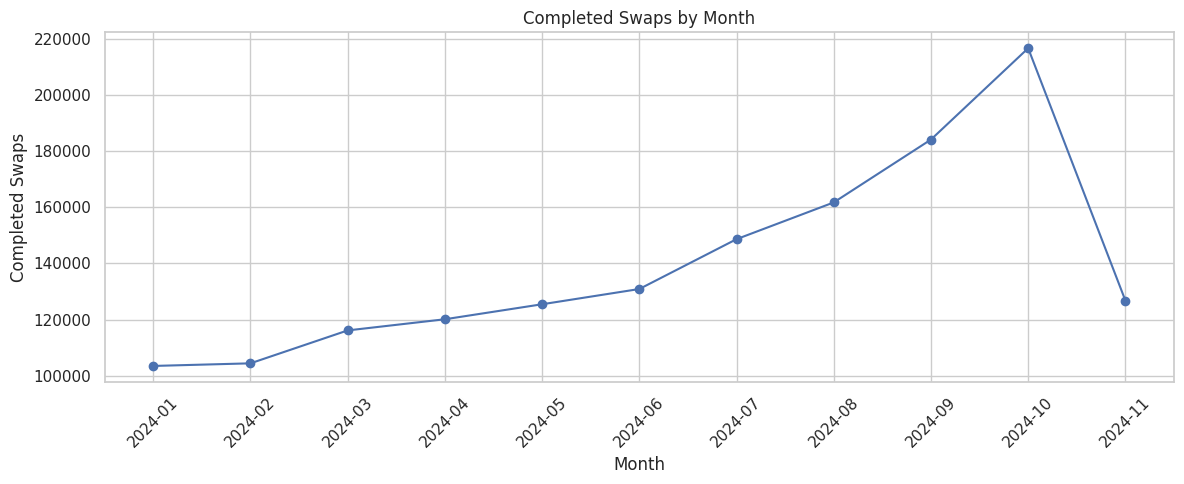

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_network.index.astype(str),
    monthly_network["completed_swaps"],
    marker="o"
)

plt.title("Completed Swaps by Month")
plt.xlabel("Month")
plt.ylabel("Completed Swaps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7.3 Network Performance Trend Analysis

The monthly metrics show how network activity, revenue and service
reliability changed over the available swap-event period.

Because November 2024 contains data only through November 18, it is
treated as a partial month when interpreting volume and revenue.

The analysis therefore focuses on the completed months from January
through October when comparing monthly network scale.

In [145]:
# Use complete months for Jan-Oct comparison

complete_months = monthly_network.loc["2024-01":"2024-10"]

jan = complete_months.iloc[0]
october = complete_months.iloc[-1]

completed_swap_growth = (
    (october["completed_swaps"] - jan["completed_swaps"])
    / jan["completed_swaps"]
    * 100
)

revenue_growth = (
    (october["revenue_inr"] - jan["revenue_inr"])
    / jan["revenue_inr"]
    * 100
)

failure_rate_change = (
    october["failure_rate_pct"]
    - jan["failure_rate_pct"]
)

peak_failure_month = monthly_network["failure_rate_pct"].idxmax()
peak_failure_rate = monthly_network["failure_rate_pct"].max()

print("Network Trend Summary")
print("=" * 70)

print(f"Completed swaps growth, Jan → Oct : {completed_swap_growth:.2f}%")
print(f"Revenue growth, Jan → Oct         : {revenue_growth:.2f}%")
print(f"Failure-rate change, Jan → Oct    : {failure_rate_change:.2f} percentage points")

print(
    f"\nHighest failure-rate month       : "
    f"{peak_failure_month}"
)
print(
    f"Highest failure rate             : "
    f"{peak_failure_rate:.2f}%"
)

Network Trend Summary
Completed swaps growth, Jan → Oct : 109.21%
Revenue growth, Jan → Oct         : 131.47%
Failure-rate change, Jan → Oct    : -0.03 percentage points

Highest failure-rate month       : 2024-05
Highest failure rate             : 12.39%


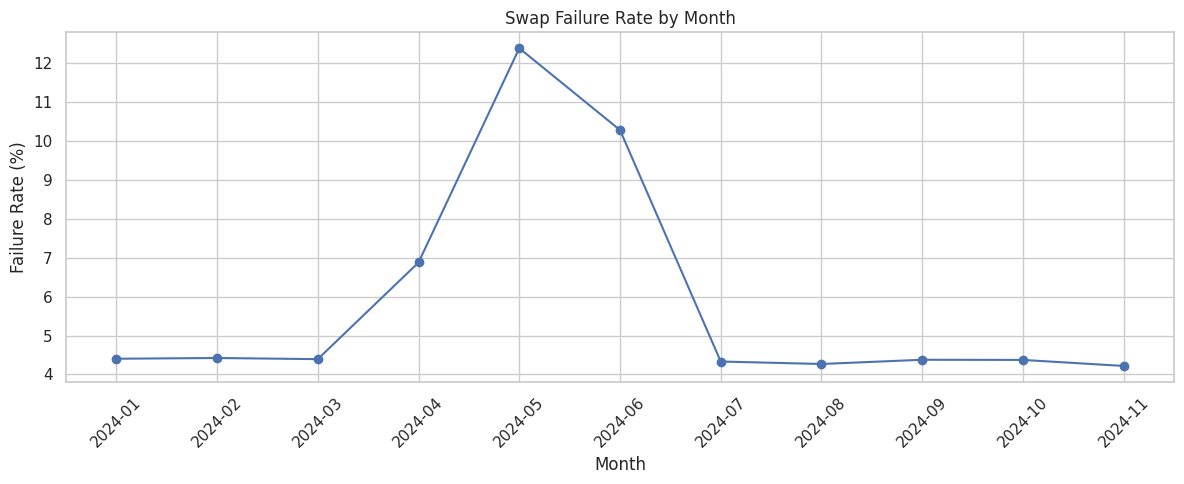

In [146]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_network.index.astype(str),
    monthly_network["failure_rate_pct"],
    marker="o"
)

plt.title("Swap Failure Rate by Month")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7.4 Investigating the Failure-Rate Spike

The monthly analysis identified a pronounced increase in swap failures
during April, May and June 2024, with the highest failure rate occurring
in May.

The next step is to determine whether the increase was concentrated in
specific failure types rather than treating all unsuccessful events as
one category.

This helps identify the operational nature of the reliability problem.

In [147]:
# Failure type by month

failure_type_monthly = (
    df_swaps_clean
    .groupby(["month", "event_type"])
    .size()
    .unstack(fill_value=0)
)

print("Event Types by Month")
print("=" * 70)

print(failure_type_monthly)

Event Types by Month
event_type  abandoned_queue  cancelled_by_rider  failed_no_charged_battery  \
month                                                                        
2024-01                1371                 443                       2643   
2024-02                1421                 457                       2619   
2024-03                1539                 544                       2875   
2024-04                2643                 509                       5333   
2024-05                5452                 654                      11192   
2024-06                4549                 626                       9375   
2024-07                1995                 636                       3657   
2024-08                2130                 746                       3876   
2024-09                2403                 818                       4599   
2024-10                2860                 997                       5392   
2024-11                1676                

In [148]:
# Calculate percentage of each month's events represented by each event type

failure_type_pct = (
    failure_type_monthly
    .div(
        df_swaps_clean.groupby("month").size(),
        axis=0
    )
    * 100
)

print("Event Type Percentage by Month")
print("=" * 70)

print(failure_type_pct.round(2))

Event Type Percentage by Month
event_type  abandoned_queue  cancelled_by_rider  failed_no_charged_battery  \
month                                                                        
2024-01                1.27                0.41                       2.44   
2024-02                1.30                0.42                       2.40   
2024-03                1.27                0.45                       2.37   
2024-04                2.05                0.39                       4.13   
2024-05                3.81                0.46                       7.82   
2024-06                3.12                0.43                       6.43   
2024-07                1.28                0.41                       2.35   
2024-08                1.26                0.44                       2.29   
2024-09                1.25                0.42                       2.39   
2024-10                1.26                0.44                       2.38   
2024-11                1.27      

## 7.5 Q1 — Network Performance Summary

The network experienced substantial growth in activity during the available
January–October 2024 period.

Completed swaps increased by 109.21% from January to October, while
revenue increased by 131.47%. Revenue per completed swap also increased
from approximately ₹59.89 in January to ₹66.26 in October.

However, network reliability did not improve consistently with the growth
in activity. The failure rate was approximately 4.4% during January–March,
increased sharply during April–June, and reached a peak of 12.39% in May.

The May increase was primarily associated with failed_no_charged_battery
events, which represented 7.82% of all May events, compared with 2.44% in
January. Abandoned-queue events also increased to 3.81% in May from 1.27%
in January.

By July, the failure rate had returned to approximately 4.3%, close to the
level observed before the April–June disruption.

Overall, the network expanded significantly while experiencing a temporary
but substantial deterioration in service reliability. The next analysis
therefore investigates where and under what operating conditions these
failures were concentrated.

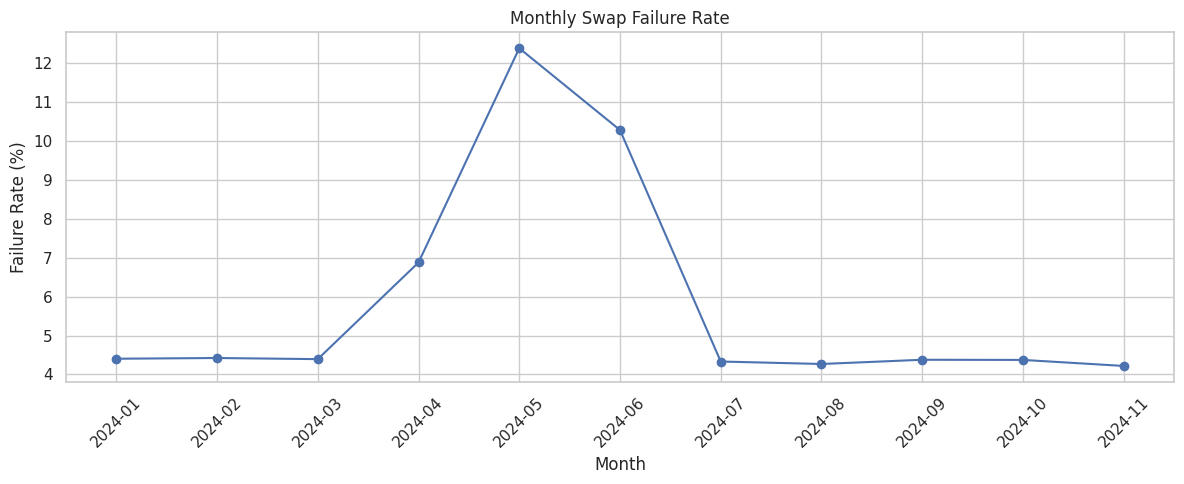

In [149]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_network.index.astype(str),
    monthly_network["failure_rate_pct"],
    marker="o"
)

plt.title("Monthly Swap Failure Rate")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8. Q2 — Service Failures & Customer Experience

The second analysis investigates the operational conditions associated
with unsuccessful swap attempts.

The analysis examines:

- Failure type
- Station
- Time of day
- Vehicle class
- Queue waiting time

The objective is to determine whether service failures are concentrated
in particular operating conditions or are broadly distributed across the
network.

The analysis describes associations in the observed data and does not
assume that any individual factor directly causes a failure.

### 8.1 Failure Definition

For service-reliability analysis, a completed swap is treated as a
successful transaction.

All other event types are treated as unsuccessful swap attempts.

The unsuccessful events are separated into their recorded categories:

- failed_no_charged_battery
- abandoned_queue
- cancelled_by_rider
- failed_system_error

In [150]:
# Create a service-failure summary

failure_summary = (
    df_swaps_clean
    .groupby("event_type")
    .size()
    .sort_values(ascending=False)
)

print("Service Event Summary")
print("=" * 70)
print(failure_summary)

print("\nFailure events only:")
print("=" * 70)

print(
    failure_summary[
        failure_summary.index != "swap_completed"
    ]
)

Service Event Summary
event_type
swap_completed               1538212
failed_no_charged_battery      54514
abandoned_queue                28039
cancelled_by_rider              6981
failed_system_error             4882
dtype: int64

Failure events only:
event_type
failed_no_charged_battery    54514
abandoned_queue              28039
cancelled_by_rider            6981
failed_system_error           4882
dtype: int64


## 8.2 Failure Rate by City

Failure rates are compared across the six operating cities to determine
whether service reliability problems are concentrated geographically.

Both total swap activity and failure rate are considered because a city
with a large number of failures may simply have a larger transaction
volume.

The comparison uses the observed swap events in the cleaned dataset.

In [151]:
# Merge city information into the cleaned swap events

df_q2 = df_swaps_clean.merge(
    df_stations[["station_id", "city"]],
    on="station_id",
    how="left"
)

# Calculate city-level service metrics

city_failure = (
    df_q2
    .groupby("city")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        failed_events=("is_failure", "sum")
    )
)

city_failure["failure_rate_pct"] = (
    city_failure["failed_events"]
    / city_failure["total_events"]
    * 100
)

city_failure = city_failure.sort_values(
    "failure_rate_pct",
    ascending=False
)

print("Failure Rate by City")
print("=" * 70)

print(city_failure.round(2))

Failure Rate by City
           total_events  completed_swaps  failed_events  failure_rate_pct
city                                                                     
Jaipur           206873           190942          15931              7.70
Delhi NCR        316810           294976          21834              6.89
Hyderabad        301355           282080          19275              6.40
Pune             246677           234461          12216              4.95
Bengaluru        332743           317705          15038              4.52
Mumbai           228170           218048          10122              4.44


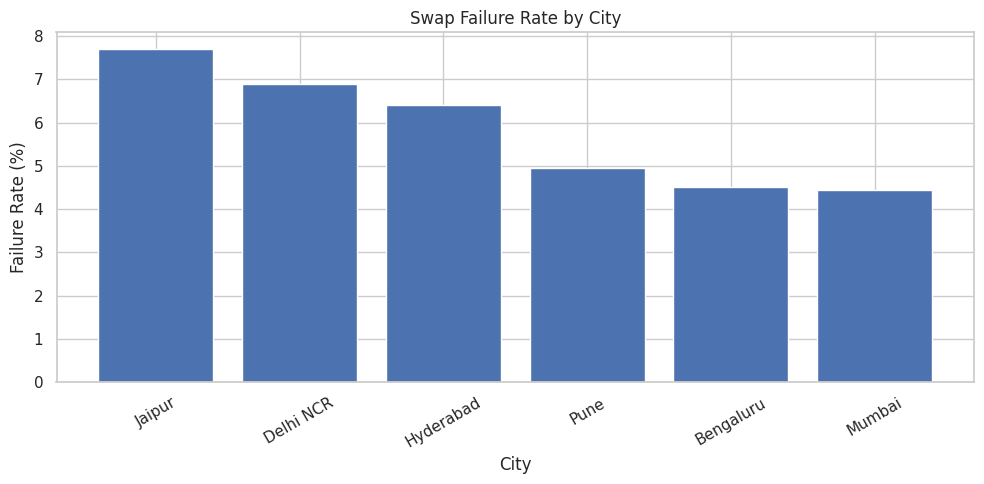

In [152]:
plt.figure(figsize=(10, 5))

plt.bar(
    city_failure.index,
    city_failure["failure_rate_pct"]
)

plt.title("Swap Failure Rate by City")
plt.xlabel("City")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 8.3 Failure Rate by Hour of Day

Service failures are examined across different hours of the day to
identify whether reliability varies with operating time.

This helps determine whether failures are concentrated during particular
periods of daily activity rather than being evenly distributed throughout
the day.

In [153]:
# Extract hour from the swap timestamp

df_q2["hour"] = df_q2["event_ts"].dt.hour

hourly_failure = (
    df_q2
    .groupby("hour")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        failed_events=("is_failure", "sum")
    )
)

hourly_failure["failure_rate_pct"] = (
    hourly_failure["failed_events"]
    / hourly_failure["total_events"]
    * 100
)

print("Failure Rate by Hour")
print("=" * 70)

print(hourly_failure.round(2))

Failure Rate by Hour
      total_events  completed_swaps  failed_events  failure_rate_pct
hour                                                                
0             9422             8901            521              5.53
1             9260             8757            503              5.43
2             9236             8767            469              5.08
3             9336             8816            520              5.57
4             9903             9393            510              5.15
5             9627             9131            496              5.15
6            23286            22010           1276              5.48
7            23473            22196           1277              5.44
8            70635            66765           3870              5.48
9            99683            94245           5438              5.46
10           58236            54893           3343              5.74
11           43159            40564           2595              6.01
12          1

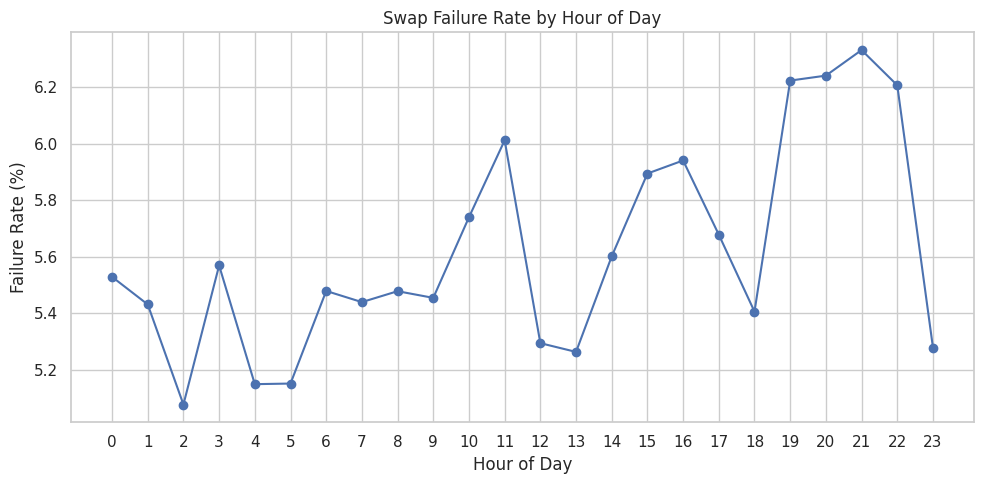

In [154]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_failure.index,
    hourly_failure["failure_rate_pct"],
    marker="o"
)

plt.title("Swap Failure Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Failure Rate (%)")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

## 8.4 Failure Rate by Vehicle Class

Service reliability is compared across vehicle classes to determine
whether unsuccessful swap attempts differ between 2W and 3W vehicles.

This comparison helps identify whether vehicle type is associated with
different levels of service failure in the observed data.

In [155]:
# Add vehicle class information from the rider dataset

df_q2_vehicle = df_q2.merge(
    df_riders[["rider_id", "vehicle_class"]],
    on="rider_id",
    how="left"
)

vehicle_failure = (
    df_q2_vehicle
    .groupby("vehicle_class")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        failed_events=("is_failure", "sum")
    )
)

vehicle_failure["failure_rate_pct"] = (
    vehicle_failure["failed_events"]
    / vehicle_failure["total_events"]
    * 100
)

print("Failure Rate by Vehicle Class")
print("=" * 70)

print(vehicle_failure.round(2))

Failure Rate by Vehicle Class
               total_events  completed_swaps  failed_events  failure_rate_pct
vehicle_class                                                                
2W                  1450161          1374398          75763              5.22
3W                   182467           163814          18653             10.22


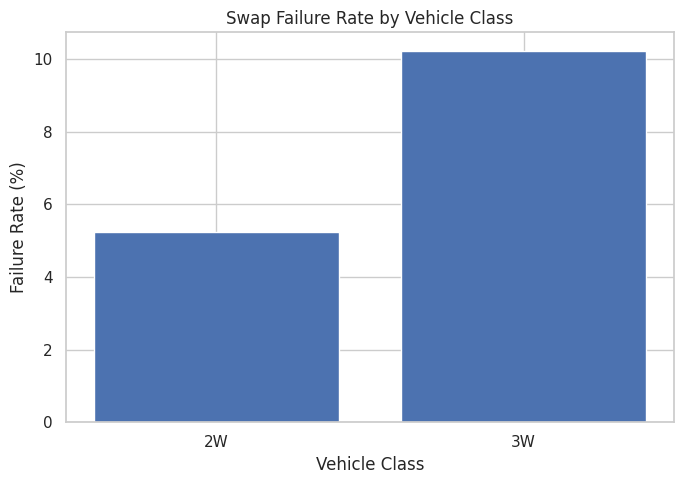

In [156]:
plt.figure(figsize=(7, 5))

plt.bar(
    vehicle_failure.index,
    vehicle_failure["failure_rate_pct"]
)

plt.title("Swap Failure Rate by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Failure Rate (%)")

plt.tight_layout()
plt.show()

## 8.5 Queue Wait Time and Customer Abandonment

Queue waiting time is examined to understand its relationship with
unsuccessful customer attempts.

Particular attention is given to abandoned-queue events because these
represent attempts where the rider did not complete the swap after
entering the service process.

The analysis compares queue waiting times for completed swaps and
abandoned-queue events.

In [157]:
# Compare queue wait time for completed and abandoned-queue events

queue_analysis = (
    df_swaps_clean[
        df_swaps_clean["event_type"].isin(
            ["swap_completed", "abandoned_queue"]
        )
    ]
    .groupby("event_type")["queue_wait_sec"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        max="max"
    )
)

print("Queue Wait Time Comparison")
print("=" * 70)

print(queue_analysis.round(2))

Queue Wait Time Comparison
                   count    mean  median   max
event_type                                    
abandoned_queue    28039  701.84   647.0  2400
swap_completed   1538212  243.67   209.0  1800


In [158]:
# Create wait-time buckets

queue_data = df_swaps_clean[
    df_swaps_clean["event_type"].isin(
        ["swap_completed", "abandoned_queue"]
    )
].copy()

queue_data["wait_bucket"] = pd.cut(
    queue_data["queue_wait_sec"],
    bins=[-1, 60, 120, 300, 600, float("inf")],
    labels=[
        "0–60 sec",
        "61–120 sec",
        "121–300 sec",
        "301–600 sec",
        "600+ sec"
    ]
)

queue_bucket = (
    queue_data
    .groupby("wait_bucket", observed=False)
    .agg(
        total_events=("event_id", "count"),
        abandoned_events=(
            "event_type",
            lambda x: (x == "abandoned_queue").sum()
        )
    )
)

queue_bucket["abandonment_rate_pct"] = (
    queue_bucket["abandoned_events"]
    / queue_bucket["total_events"]
    * 100
)

print("Abandonment Rate by Queue Wait Time")
print("=" * 70)

print(queue_bucket.round(2))

Abandonment Rate by Queue Wait Time
             total_events  abandoned_events  abandonment_rate_pct
wait_bucket                                                      
0–60 sec            18922                 0                  0.00
61–120 sec         223826                 0                  0.00
121–300 sec        902539               778                  0.09
301–600 sec        362027             11110                  3.07
600+ sec            58937             16151                 27.40


## 8.6 Q2 — Service Failures & Customer Experience Findings

The service-failure analysis shows that unsuccessful swap attempts are not
uniformly distributed across the network.

### Geographic variation

Failure rates differed substantially across cities. Jaipur recorded the
highest observed failure rate at 7.70%, followed by Delhi NCR at 6.89% and
Hyderabad at 6.40%. Mumbai recorded the lowest observed rate at 4.44%.

This indicates that service reliability varies geographically and should
be investigated at the station and operating-condition level.

### Time-of-day variation

Failure rates were relatively stable across most hours but increased during
the evening. The highest observed hourly failure rate was 6.33% at 21:00,
with rates above 6% also observed at 19:00, 20:00 and 22:00.

### Vehicle-class variation

3W events had a substantially higher observed failure rate than 2W events.
The failure rate was 10.22% for 3W compared with 5.22% for 2W.

### Queue and customer experience

Queue waiting time showed a strong relationship with abandoned-queue events.
The median wait was 209 seconds for completed swaps compared with 647 seconds
for abandoned queues.

Abandonment was rare below 300 seconds, increased to 3.07% for waits between
301 and 600 seconds, and reached 27.40% for waits above 600 seconds.

### Overall interpretation

The Q2 analysis identifies several important operational patterns:
geographic variation, evening-period variation, higher failure rates among
3W events, and a strong association between long queue waits and
abandonment.

These findings identify where deeper investigation should be focused, but
they do not by themselves establish that any individual factor directly
causes service failure.

## 9.1 Failure Rate by Station

Station-level failure rates are examined to determine whether the
geographic differences observed at the city level are concentrated in
specific stations.

Stations with very different transaction volumes are compared using
failure rate alongside event volume.

In [159]:
station_failure = (
    df_q2
    .groupby("station_id")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        failed_events=("is_failure", "sum")
    )
)

station_failure["failure_rate_pct"] = (
    station_failure["failed_events"]
    / station_failure["total_events"]
    * 100
)

station_failure = station_failure.sort_values(
    "failure_rate_pct",
    ascending=False
)

print("Top 15 Stations by Failure Rate")
print("=" * 70)

print(
    station_failure.head(15).round(2)
)

Top 15 Stations by Failure Rate
             total_events  completed_swaps  failed_events  failure_rate_pct
station_id                                                                 
STN-DEL-037         14553            13337           1216              8.36
STN-JAI-133         15089            13852           1237              8.20
STN-JAI-142         17509            16087           1422              8.12
STN-JAI-138         24587            22599           1988              8.09
STN-JAI-139         17039            15662           1377              8.08
STN-JAI-137         21770            20038           1732              7.96
STN-JAI-136         15725            14486           1239              7.88
STN-JAI-140         22365            20615           1750              7.82
STN-DEL-048         16006            14758           1248              7.80
STN-DEL-039         16381            15104           1277              7.80
STN-JAI-135         16597            15315           128

In [160]:
print("\nBottom 15 Stations by Failure Rate")
print("=" * 70)

print(
    station_failure.tail(15).round(2)
)


Bottom 15 Stations by Failure Rate
             total_events  completed_swaps  failed_events  failure_rate_pct
station_id                                                                 
STN-BLR-016         10772            10318            454              4.21
STN-BLR-020         11921            11424            497              4.17
STN-BLR-022          2053             1968             85              4.14
STN-MUM-116         17512            16795            717              4.09
STN-BLR-024          4536             4352            184              4.06
STN-HYD-080          1140             1094             46              4.04
STN-DEL-056          1191             1143             48              4.03
STN-DEL-053          4713             4525            188              3.99
STN-JAI-146          4582             4401            181              3.95
STN-PUN-103          1651             1586             65              3.94
STN-HYD-083          4406             4235          

## 9.2 Failure Rate by Station Characteristics

Station failure rates are compared across operational characteristics
including location type, charger generation and expansion wave.

These comparisons help determine whether reliability differences are
associated with the type and generation of station infrastructure.

In [161]:
# Add station characteristics to the station-level metrics

station_details = station_failure.reset_index().merge(
    df_stations[
        [
            "station_id",
            "city",
            "location_type",
            "charger_generation",
            "expansion_wave"
        ]
    ],
    on="station_id",
    how="left"
)

print("Failure Rate by Location Type")
print("=" * 70)

location_failure = (
    station_details
    .groupby("location_type")
    .agg(
        stations=("station_id", "nunique"),
        total_events=("total_events", "sum"),
        failed_events=("failed_events", "sum")
    )
)

location_failure["failure_rate_pct"] = (
    location_failure["failed_events"]
    / location_failure["total_events"]
    * 100
)

print(location_failure.round(2))

Failure Rate by Location Type
                   stations  total_events  failed_events  failure_rate_pct
location_type                                                             
commercial_hub           40        726846          42700              5.87
highway_fuel_pump        16         67274           3192              4.74
market                   33        570665          33898              5.94
residential              19        127337           6884              5.41
tech_park                 6         63854           3283              5.14
transit_hub               6         76652           4459              5.82


In [162]:
print("\nFailure Rate by Charger Generation")
print("=" * 70)

charger_failure = (
    station_details
    .groupby("charger_generation")
    .agg(
        stations=("station_id", "nunique"),
        total_events=("total_events", "sum"),
        failed_events=("failed_events", "sum")
    )
)

charger_failure["failure_rate_pct"] = (
    charger_failure["failed_events"]
    / charger_failure["total_events"]
    * 100
)

print(charger_failure.round(2))


Failure Rate by Charger Generation
                    stations  total_events  failed_events  failure_rate_pct
charger_generation                                                         
Gen1                      51        900389          60080              6.67
Gen2                      62        707213          33230              4.70
Gen3                       7         25026           1106              4.42


In [163]:
print("\nFailure Rate by Expansion Wave")
print("=" * 70)

wave_failure = (
    station_details
    .groupby("expansion_wave")
    .agg(
        stations=("station_id", "nunique"),
        total_events=("total_events", "sum"),
        failed_events=("failed_events", "sum")
    )
)

wave_failure["failure_rate_pct"] = (
    wave_failure["failed_events"]
    / wave_failure["total_events"]
    * 100
)

print(wave_failure.round(2))


Failure Rate by Expansion Wave
                stations  total_events  failed_events  failure_rate_pct
expansion_wave                                                         
Launch                90       1538147          90263              5.87
Wave1_2024H2          30         94481           4153              4.40


## 9.3 Station Failures and Battery Performance

Battery state of health (SOH) is examined to determine whether battery
condition differs between successful and unsuccessful swap attempts.

The comparison uses the SOH recorded for the incoming battery at the time
of the swap event.

Missing SOH values are excluded from the comparison rather than treated
as zero.

In [164]:
battery_soh_analysis = (
    df_swaps_clean[
        df_swaps_clean["soh_in_pct"].notna()
    ]
    .groupby("event_type")["soh_in_pct"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
)

print("Incoming Battery SOH by Event Type")
print("=" * 70)

print(battery_soh_analysis.round(2))

Incoming Battery SOH by Event Type
                             count   mean  median   min    max
event_type                                                    
abandoned_queue              27996  95.13    95.4  83.4  100.0
failed_no_charged_battery    54430  95.19    95.4  84.0  100.0
swap_completed             1535040  94.72    94.8  83.0  100.0


In [165]:
# Compare completed swaps with all unsuccessful events

soh_comparison = (
    df_swaps_clean[
        df_swaps_clean["soh_in_pct"].notna()
    ]
    .assign(
        outcome=lambda x: np.where(
            x["is_completed"],
            "Completed",
            "Failed"
        )
    )
    .groupby("outcome")["soh_in_pct"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
)

print("Battery SOH: Completed vs Failed")
print("=" * 70)

print(soh_comparison.round(2))

Battery SOH: Completed vs Failed
             count   mean  median
outcome                          
Completed  1535040  94.72    94.8
Failed       82426  95.17    95.4


## 9.4 Q3 — Station & Geographic Patterns Summary

The station-level analysis shows that service reliability varies across
the VoltRelay network.

City-level failure rates ranged from 4.44% in Mumbai to 7.70% in Jaipur,
indicating geographic variation in observed service performance.

Station location type showed relatively smaller differences, with failure
rates ranging from 4.74% at highway fuel pumps to 5.94% at markets.

A larger difference was observed across charger generations. Gen1 stations
recorded a 6.67% failure rate, compared with 4.70% for Gen2 and 4.42% for
Gen3.

Expansion-wave differences were also observed. Launch stations recorded a
5.87% failure rate compared with 4.40% for Wave1_2024H2 stations.

Incoming battery SOH did not show evidence of poorer battery health among
failed events. Mean SOH was 94.72% for completed swaps and 95.17% for failed
events.

Overall, the analysis indicates that station and infrastructure
characteristics, particularly charger generation, warrant further
investigation. However, these comparisons are observational and do not
establish direct causation.

## 10.1 Battery Supplier and Swap Performance

Battery supplier is examined to determine whether swap outcomes differ
across suppliers.

The analysis uses the incoming battery associated with each swap event
where supplier information can be identified.

In [166]:
# Connect incoming batteries to their supplier

df_q4 = df_swaps_clean.merge(
    df_batteries[
        [
            "battery_id",
            "supplier",
            "manufacturing_lot",
            "pack_type",
            "rated_capacity_kwh"
        ]
    ],
    left_on="battery_in_id",
    right_on="battery_id",
    how="left"
)

supplier_failure = (
    df_q4
    .dropna(subset=["supplier"])
    .groupby("supplier")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        failed_events=("is_failure", "sum")
    )
)

supplier_failure["failure_rate_pct"] = (
    supplier_failure["failed_events"]
    / supplier_failure["total_events"]
    * 100
)

print("Failure Rate by Battery Supplier")
print("=" * 70)

print(supplier_failure.round(2))

Failure Rate by Battery Supplier
          total_events  completed_swaps  failed_events  failure_rate_pct
supplier                                                                
Amptek          384144           364157          19987              5.20
Cellora        1051343           997446          53897              5.13
Kyron           185277           176608           8669              4.68


In [167]:
print("\nBattery Supplier Event Counts")
print("=" * 70)

print(
    supplier_failure[
        ["total_events", "completed_swaps", "failed_events"]
    ]
)


Battery Supplier Event Counts
          total_events  completed_swaps  failed_events
supplier                                              
Amptek          384144           364157          19987
Cellora        1051343           997446          53897
Kyron           185277           176608           8669


## 10.2 Battery Manufacturing Lot Performance

Battery performance is further examined at the manufacturing-lot level.

This helps identify whether variation within a supplier is associated with
different observed swap outcomes.

Only manufacturing lots with sufficient transaction volume should be
considered when interpreting differences.

In [168]:
lot_failure = (
    df_q4
    .dropna(subset=["manufacturing_lot"])
    .groupby("manufacturing_lot")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        failed_events=("is_failure", "sum"),
        avg_soh=("soh_in_pct", "mean")
    )
)

lot_failure["failure_rate_pct"] = (
    lot_failure["failed_events"]
    / lot_failure["total_events"]
    * 100
)

# Show lots with at least 1,000 observed events
lot_failure_filtered = (
    lot_failure[
        lot_failure["total_events"] >= 1000
    ]
    .sort_values(
        "failure_rate_pct",
        ascending=False
    )
)

print("Manufacturing Lots with at least 1,000 Events")
print("=" * 70)

print(lot_failure_filtered.round(2))

Manufacturing Lots with at least 1,000 Events
                   total_events  completed_swaps  failed_events  avg_soh  \
manufacturing_lot                                                          
KY-2418                    2517             2261            256    96.44   
KY-2416                    3657             3295            362    96.59   
KY-2414                    2988             2697            291    96.51   
KY-2410                    3140             2841            299    96.49   
KY-2411                    3909             3538            371    96.49   
KY-2412                    3856             3493            363    96.43   
KY-2415                    4340             3932            408    96.51   
KY-2413                    4510             4101            409    96.56   
KY-2417                    3708             3384            324    96.50   
AM-2506                   13746            12998            748    94.73   
AM-2403                   24986           

## 10.3 Battery Health and Swap Performance

Battery state of health (SOH) is examined across ranges of battery
condition to determine whether swap outcomes vary with battery health.

The analysis uses the incoming battery SOH recorded at the time of each
swap event.

This helps distinguish general battery-health effects from the
manufacturing-lot patterns observed above.

In [169]:
# Create SOH ranges

soh_data = df_swaps_clean[
    df_swaps_clean["soh_in_pct"].notna()
].copy()

soh_data["soh_bucket"] = pd.cut(
    soh_data["soh_in_pct"],
    bins=[0, 90, 92, 94, 96, 98, 100],
    labels=[
        "<=90%",
        "90–92%",
        "92–94%",
        "94–96%",
        "96–98%",
        "98–100%"
    ],
    include_lowest=True
)

soh_failure = (
    soh_data
    .groupby("soh_bucket", observed=False)
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        failed_events=("is_failure", "sum")
    )
)

soh_failure["failure_rate_pct"] = (
    soh_failure["failed_events"]
    / soh_failure["total_events"]
    * 100
)

print("Failure Rate by Incoming Battery SOH")
print("=" * 70)

print(soh_failure.round(2))

Failure Rate by Incoming Battery SOH
            total_events  completed_swaps  failed_events  failure_rate_pct
soh_bucket                                                                
<=90%              70593            68237           2356              3.34
90–92%            264937           256597           8340              3.15
92–94%            329400           316969          12431              3.77
94–96%            353559           326035          27524              7.78
96–98%            370393           348034          22359              6.04
98–100%           228584           219168           9416              4.12


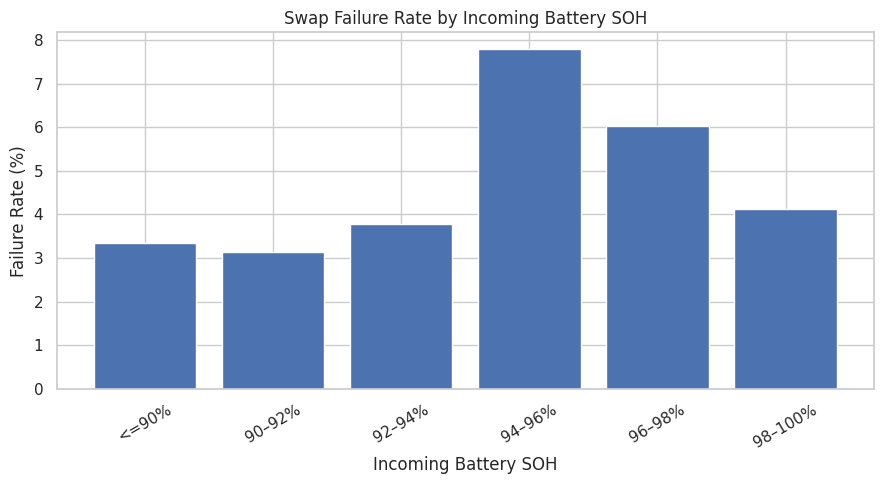

In [170]:
plt.figure(figsize=(9, 5))

plt.bar(
    soh_failure.index.astype(str),
    soh_failure["failure_rate_pct"]
)

plt.title("Swap Failure Rate by Incoming Battery SOH")
plt.xlabel("Incoming Battery SOH")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 10.4 Q4 — Battery & Equipment Performance Summary

The battery analysis shows that supplier-level differences in failure rates
were relatively small. Observed failure rates were 5.20% for Amptek, 5.13%
for Cellora and 4.68% for Kyron.

However, manufacturing-lot analysis revealed substantial variation within
Kyron. Earlier Kyron lots such as KY-2407, KY-2408 and KY-2409 had failure
rates below 4%, while later Kyron lots from KY-2410 through KY-2418 had
failure rates ranging from approximately 8.74% to 10.17%.

Battery SOH did not show a simple relationship with service failures.
Completed swaps had a mean incoming SOH of 94.72%, while failed events had
a slightly higher mean of 95.17%.

When grouped into SOH ranges, the highest observed failure rate was 7.78%
for batteries with 94–96% SOH, while batteries in the 90–92% range had a
3.15% failure rate.

Overall, supplier averages alone do not explain battery-related service
variation. Manufacturing cohorts show larger differences, while current
SOH does not display a simple monotonic relationship with failure rate.
These results identify battery cohorts as an area for further operational
investigation rather than establishing a direct causal relationship.

## 11.1 Revenue and Pricing Structure

The analysis examines transaction pricing across tariff codes to understand
how pricing structures are associated with charged amounts and transaction
volume.

Only financially complete transactions are included in the revenue
calculation.

In [171]:
tariff_analysis = (
    financial_df[
        financial_df["is_completed"]
    ]
    .groupby("tariff_code")
    .agg(
        completed_swaps=("event_id", "count"),
        revenue_inr=("amount_charged_inr", "sum"),
        avg_amount_charged_inr=("amount_charged_inr", "mean"),
        avg_discount_inr=("discount_inr", "mean"),
        avg_list_price_inr=("list_price_inr", "mean")
    )
)

tariff_analysis["revenue_share_pct"] = (
    tariff_analysis["revenue_inr"]
    / tariff_analysis["revenue_inr"].sum()
    * 100
)

print("Pricing Performance by Tariff")
print("=" * 70)

print(tariff_analysis.round(2))

Pricing Performance by Tariff
             completed_swaps  revenue_inr  avg_amount_charged_inr  \
tariff_code                                                         
OFFPEAK                 4951     293117.0                   59.20   
PARTNER              1017505   62372088.5                   61.30   
PEAK                   22877    1885810.0                   82.43   
STD                   492878   32021490.0                   64.97   

             avg_discount_inr  avg_list_price_inr  revenue_share_pct  
tariff_code                                                           
OFFPEAK                  0.00               67.20               0.30  
PARTNER                  7.35               68.37              64.59  
PEAK                     0.00               67.43               1.95  
STD                      0.00               64.97              33.16  


## 11.2 Fleet Partner Economics

Fleet partners represent an important part of VoltRelay's transaction
volume. This analysis compares partner segments and contractual pricing
terms to understand differences in swap volume, discounts and realized
revenue.

The analysis focuses on observed commercial differences rather than
assuming that contract terms directly cause changes in performance.

In [172]:
# First connect completed swaps with rider information
partner_swaps = (
    financial_df[
        financial_df["is_completed"] &
        financial_df["rider_id"].notna()
    ]
    .merge(
        df_riders[
            ["rider_id", "partner_id"]
        ],
        on="rider_id",
        how="left"
    )
)

# Then connect riders to fleet-partner information
partner_swaps = partner_swaps.merge(
    df_partners[
        [
            "partner_id",
            "partner_name",
            "partner_segment",
            "vehicle_class",
            "contract_type",
            "discount_pct",
            "discount_pct_after_amendment",
            "peak_surcharge_billable"
        ]
    ],
    on="partner_id",
    how="left"
)

# Calculate partner-level economics
partner_analysis = (
    partner_swaps[
        partner_swaps["partner_id"].notna()
    ]
    .groupby(
        [
            "partner_id",
            "partner_name",
            "partner_segment",
            "vehicle_class"
        ]
    )
    .agg(
        completed_swaps=("event_id", "count"),
        revenue_inr=("amount_charged_inr", "sum"),
        avg_amount_charged_inr=("amount_charged_inr", "mean"),
        avg_discount_inr=("discount_inr", "mean"),
        contract_discount_pct=("discount_pct", "first"),
        amended_discount_pct=("discount_pct_after_amendment", "first"),
        peak_surcharge_billable=("peak_surcharge_billable", "first")
    )
    .sort_values("revenue_inr", ascending=False)
)

print("Fleet Partner Economics")
print("=" * 90)

print(partner_analysis.round(2))

Fleet Partner Economics
                                                       completed_swaps  \
partner_id partner_name partner_segment vehicle_class                    
FP-03      ZipDrop      quick_commerce  2W                      232542   
FP-01      FeastFly     food_delivery   2W                      220898   
FP-02      ParcelNest   ecom_logistics  2W                      129398   
FP-05      Swiggle Go   food_delivery   2W                      104176   
FP-04      CargoTuk     cargo_3w        3W                       57030   
FP-07      QuickCart    quick_commerce  2W                       56936   
FP-06      RideMitra    bike_taxi       2W                       48852   
FP-08      DabbaXpress  food_delivery   2W                       38503   
FP-09      HaulKing     cargo_3w        3W                       23992   
FP-12      UrbanErrand  bike_taxi       2W                       37422   
FP-11      LastMileHub  ecom_logistics  2W                       33890   
FP-10      Met

## 11.3 Contract Amendment and Pricing Change

The fleet-partner data indicates that ZipDrop's contracted discount changed
from 12% to 28%.

This section compares ZipDrop transactions before and after the contract
amendment to examine changes in swap volume, realized revenue and average
amount charged.

The comparison is descriptive and does not establish that the contract
amendment caused any observed change.

In [173]:
# Get ZipDrop's contract amendment date
zipdrop_contract = df_partners[
    df_partners["partner_id"] == "FP-03"
][
    [
        "partner_id",
        "partner_name",
        "discount_pct",
        "amendment_date",
        "discount_pct_after_amendment"
    ]
]

print("ZipDrop Contract Details")
print("=" * 70)
print(zipdrop_contract)

ZipDrop Contract Details
  partner_id partner_name  discount_pct amendment_date  \
2      FP-03      ZipDrop          12.0     2024-11-01   

   discount_pct_after_amendment  
2                          28.0  


## 11.4 Before vs After ZipDrop Contract Amendment

ZipDrop's contract was amended on 1 November 2024, increasing the
contracted discount from 12% to 28%.

Transactions are compared before and after the amendment to examine
changes in swap volume, realized revenue, average charge and discount.

Because the available swap data ends on 18 November 2024, the post-
amendment period contains only a limited number of days. Therefore, the
comparison should be interpreted cautiously.

In [174]:
zipdrop = partner_swaps[
    partner_swaps["partner_id"] == "FP-03"
].copy()

zipdrop["period"] = np.where(
    zipdrop["event_ts"] < pd.Timestamp("2024-11-01"),
    "Before amendment",
    "After amendment"
)

zipdrop_comparison = (
    zipdrop
    .groupby("period")
    .agg(
        completed_swaps=("event_id", "count"),
        revenue_inr=("amount_charged_inr", "sum"),
        avg_amount_charged_inr=("amount_charged_inr", "mean"),
        avg_discount_inr=("discount_inr", "mean"),
        avg_list_price_inr=("list_price_inr", "mean")
    )
)

zipdrop_comparison["revenue_per_swap"] = (
    zipdrop_comparison["revenue_inr"]
    / zipdrop_comparison["completed_swaps"]
)

print("ZipDrop: Before vs After Contract Amendment")
print("=" * 80)

print(zipdrop_comparison.round(2))

ZipDrop: Before vs After Contract Amendment
                  completed_swaps  revenue_inr  avg_amount_charged_inr  \
period                                                                   
After amendment             19574     952328.6                   48.65   
Before amendment           212968   12242088.4                   57.48   

                  avg_discount_inr  avg_list_price_inr  revenue_per_swap  
period                                                                    
After amendment              18.92               67.58             48.65  
Before amendment              7.84               65.32             57.48  


## 11.5 Q5 — Pricing & Partner Economics Summary

Pricing analysis shows that PARTNER transactions represented the largest
share of completed swaps and revenue, with 1,017,505 completed swaps and
64.59% of observed revenue. The average amount charged for PARTNER
transactions was ₹61.30 after an average discount of ₹7.35.

Standard transactions had an average charge of ₹64.97, while PEAK
transactions had the highest average charge at ₹82.43. However, PEAK
transactions represented only a small share of total completed swaps.

Fleet-partner economics varied substantially across partners and vehicle
classes. The largest partners by completed swap volume included ZipDrop,
FeastFly and ParcelNest. The 3W partners had substantially higher average
charges per swap than most 2W partners, so partner economics should be
interpreted together with vehicle class.

ZipDrop's contract was amended on 1 November 2024, increasing the
contracted discount from 12% to 28%. After the amendment, the observed
average discount increased from ₹7.84 to ₹18.92, while average amount
charged decreased from ₹57.48 to ₹48.65.

The post-amendment period contains only 18 days of available data.
Therefore, the observed change should be treated as an association rather
than proof of causation.

Overall, pricing and partner terms appear to be important contributors to
revenue-per-swap variation, with the largest commercial effect observed
around the ZipDrop contract amendment.

## 12.1 Rider Retention and Cohort Analysis

Rider retention is analyzed using signup-based cohorts.

A rider is considered retained when they complete a subsequent swap after
their initial activity. Cohort-based analysis helps avoid treating recently
registered riders as churned simply because they have not yet had enough
time to return.

The analysis focuses on new-rider behavior and subsequent completed swaps.

In [175]:
print("Rider signup date range:")
print(df_riders["signup_date"].min(), "to", df_riders["signup_date"].max())

print("\nCompleted swap date range:")
print(
    df_swaps_clean.loc[
        df_swaps_clean["is_completed"],
        "event_ts"
    ].min(),
    "to",
    df_swaps_clean.loc[
        df_swaps_clean["is_completed"],
        "event_ts"
    ].max()
)

Rider signup date range:
2023-03-08 to 2025-06-30

Completed swap date range:
2024-01-01 00:00:33 to 2024-11-18 23:57:03


## 12.2 30-Day Rider Retention

To measure new-rider retention fairly, riders must have enough observation
time after their first completed swap.

A rider is included in the 30-day retention cohort only when their first
completed swap occurred at least 30 days before the end of the available
swap-event data.

A rider is considered retained if they complete at least one additional
swap within 30 days of their first completed swap.

This definition avoids classifying recently acquired riders as churned
when their observation window is incomplete.

In [176]:
# Completed swaps only
completed = df_swaps_clean[
    df_swaps_clean["is_completed"]
].copy()

# First completed swap for each rider
first_swap = (
    completed
    .groupby("rider_id")["event_ts"]
    .min()
    .reset_index()
    .rename(columns={"event_ts": "first_swap_ts"})
)

# Last date available in the swap dataset
last_swap_date = completed["event_ts"].max()

# Keep riders with a full 30-day observation window
eligible_riders = first_swap[
    first_swap["first_swap_ts"] <=
    last_swap_date - pd.Timedelta(days=30)
].copy()

print("Last observed completed swap:")
print(last_swap_date)

print("\nTotal riders with completed swaps:")
print(first_swap["rider_id"].nunique())

print("\nEligible riders for 30-day retention:")
print(eligible_riders["rider_id"].nunique())

Last observed completed swap:
2024-11-18 23:57:03

Total riders with completed swaps:
11746

Eligible riders for 30-day retention:
10682


## 12.3 Corrected New-Rider Retention Definition

Because the objective is to understand new-rider retention, retention is
anchored to the rider's signup date rather than simply treating the first
swap visible in the transaction dataset as the start of the rider journey.

Riders must have sufficient observation time within the available swap
data. The analysis then identifies their first completed swap and checks
whether they completed another swap within 30 days after that first swap.

This approach is more appropriate for investigating new-rider retention
and avoids overstating retention because of the limited transaction
observation window.

In [177]:
# Convert signup dates
df_riders["signup_date"] = pd.to_datetime(
    df_riders["signup_date"]
)

# Get first completed swap for every rider
first_completed = (
    completed
    .groupby("rider_id")["event_ts"]
    .min()
    .reset_index()
    .rename(columns={"event_ts": "first_swap_ts"})
)

# Attach signup information
retention_base = (
    df_riders[
        ["rider_id", "signup_date", "vehicle_class",
         "home_city", "partner_id", "plan_type"]
    ]
    .merge(
        first_completed,
        on="rider_id",
        how="inner"
    )
)

# Days from signup to first completed swap
retention_base["signup_to_first_swap_days"] = (
    retention_base["first_swap_ts"]
    - retention_base["signup_date"]
).dt.total_seconds() / (24 * 60 * 60)

print("Riders with signup + completed swap:")
print(len(retention_base))

print("\nSignup-to-first-swap summary:")
print(
    retention_base["signup_to_first_swap_days"]
    .describe()
    .round(2)
)

Riders with signup + completed swap:
11746

Signup-to-first-swap summary:
count    11746.00
mean        51.82
std         87.00
min          0.00
25%          0.84
50%          1.81
75%         82.49
max        311.50
Name: signup_to_first_swap_days, dtype: float64


## 12.4 Repeat-Swap Behavior

Before interpreting the retention rate, the distribution of completed swaps
per rider is examined.

This helps distinguish riders who used the network repeatedly from riders
who completed only a small number of swaps and provides a sanity check on
the retention calculation.

In [178]:
# Count completed swaps for each rider
rider_swap_counts = (
    completed
    .groupby("rider_id")
    .size()
    .reset_index(name="completed_swap_count")
)

print("Completed swaps per rider:")
print(rider_swap_counts["completed_swap_count"].describe())

print("\nRiders by number of completed swaps:")
print(
    rider_swap_counts["completed_swap_count"]
    .value_counts()
    .sort_index()
    .head(20)
)

print("\nRiders with exactly 1 completed swap:")
print(
    (rider_swap_counts["completed_swap_count"] == 1).sum()
)

print("\nRiders with 2 or more completed swaps:")
print(
    (rider_swap_counts["completed_swap_count"] >= 2).sum()
)

Completed swaps per rider:
count    11746.000000
mean       130.956240
std        101.976958
min          1.000000
25%         41.000000
50%        109.000000
75%        206.000000
max        503.000000
Name: completed_swap_count, dtype: float64

Riders by number of completed swaps:
completed_swap_count
1     76
2     62
3     71
4     85
5     70
6     97
7     81
8     75
9     79
10    76
11    85
12    88
13    73
14    83
15    78
16    72
17    82
18    74
19    76
20    74
Name: count, dtype: int64

Riders with exactly 1 completed swap:
76

Riders with 2 or more completed swaps:
11670


## 12.5 Time to Second Completed Swap

To validate the retention measure, the time between a rider's first and
second completed swaps is calculated.

This distinguishes riders who returned shortly after their first swap
from riders who eventually returned after a longer period.

In [179]:

# Sort completed swaps by rider and time
completed_sorted = completed.sort_values(
    ["rider_id", "event_ts"]
).copy()

# Get first and second completed swap for each rider
first_two_swaps = (
    completed_sorted
    .groupby("rider_id")
    .head(2)
    .copy()
)

# Assign swap order
first_two_swaps["swap_number"] = (
    first_two_swaps
    .groupby("rider_id")
    .cumcount() + 1
)

# Put first and second swap timestamps into separate columns
first_second = (
    first_two_swaps
    .pivot(
        index="rider_id",
        columns="swap_number",
        values="event_ts"
    )
    .reset_index()
)

first_second = first_second.rename(
    columns={
        1: "first_swap_ts",
        2: "second_swap_ts"
    }
)

# Keep riders who have a second completed swap
first_second = first_second.dropna(
    subset=["second_swap_ts"]
)

# Calculate time between first and second swap
first_second["days_to_second_swap"] = (
    first_second["second_swap_ts"]
    - first_second["first_swap_ts"]
).dt.total_seconds() / (24 * 60 * 60)

print("Riders with a second completed swap:")
print(len(first_second))

print("\nTime to second completed swap:")
print(
    first_second["days_to_second_swap"]
    .describe()
    .round(2)
)

print("\nPercentage returning within different periods:")

for days in [1, 7, 14, 30, 60, 90]:
    rate = (
        (first_second["days_to_second_swap"] <= days).mean()
        * 100
    )
    print(f"Within {days:>2} days: {rate:.2f}%")

Riders with a second completed swap:
11670

Time to second completed swap:
count    11670.00
mean         1.34
std          2.95
min          0.00
25%          0.62
50%          1.01
75%          1.58
max        116.79
Name: days_to_second_swap, dtype: float64

Percentage returning within different periods:
Within  1 days: 48.89%
Within  7 days: 99.32%
Within 14 days: 99.67%
Within 30 days: 99.88%
Within 60 days: 99.94%
Within 90 days: 99.97%


## 12.6 Early Rider Retention

The 30-day return rate is extremely high in the observed data, making it
less useful for distinguishing rider behavior.

Therefore, early repeat behavior is also examined using shorter windows.
The analysis measures whether a rider completes another swap within 1 day
and within 7 days of their first completed swap.

These measures provide greater variation for investigating factors
associated with early rider return.

In [180]:
# Calculate early retention rates
early_retention = {}

for days in [1, 7, 30]:
    early_retention[days] = (
        first_second["days_to_second_swap"] <= days
    ).mean() * 100

print("Early Rider Retention")
print("=" * 50)

for days, rate in early_retention.items():
    print(f"Return within {days} day(s): {rate:.2f}%")

Early Rider Retention
Return within 1 day(s): 48.89%
Return within 7 day(s): 99.32%
Return within 30 day(s): 99.88%


## 12.7 Rider-Level Retention Dataset

The rider-level retention dataset combines the first completed swap of each
eligible rider with rider and operational characteristics.

The primary outcome is whether the rider completed another swap within one
day of their first completed swap. Seven-day and 30-day return indicators
are also retained for comparison.

These variables allow retention patterns to be examined across rider
segments and the experience associated with the first completed swap.

In [181]:
# Start with riders who have a first completed swap
rider_analysis = retention_base.copy()

# Keep only riders with a complete 30-day observation window
rider_analysis = rider_analysis[
    rider_analysis["first_swap_ts"] <=
    last_swap_date - pd.Timedelta(days=30)
].copy()

# Add first completed swap details
first_swap_details = (
    completed_sorted
    .groupby("rider_id")
    .first()
    .reset_index()
)

first_swap_details = first_swap_details[
    [
        "rider_id",
        "station_id",
        "queue_wait_sec",
        "tariff_code",
        "discount_inr",
        "amount_charged_inr"
    ]
]

# Merge first-swap characteristics
rider_analysis = rider_analysis.merge(
    first_swap_details,
    on="rider_id",
    how="left"
)

# Add return timing information
rider_analysis = rider_analysis.merge(
    first_second[
        ["rider_id", "days_to_second_swap"]
    ],
    on="rider_id",
    how="left"
)

# Create retention indicators
rider_analysis["return_1d"] = (
    rider_analysis["days_to_second_swap"] <= 1
)

rider_analysis["return_7d"] = (
    rider_analysis["days_to_second_swap"] <= 7
)

rider_analysis["return_30d"] = (
    rider_analysis["days_to_second_swap"] <= 30
)

# Riders with no second swap are not retained
rider_analysis[
    ["return_1d", "return_7d", "return_30d"]
] = rider_analysis[
    ["return_1d", "return_7d", "return_30d"]
].fillna(False)

print("Rider analysis dataset shape:")
print(rider_analysis.shape)

print("\nColumns:")
print(rider_analysis.columns.tolist())

print("\nRetention summary:")
print(
    rider_analysis[
        ["return_1d", "return_7d", "return_30d"]
    ].mean().mul(100).round(2)
)

Rider analysis dataset shape:
(10682, 17)

Columns:
['rider_id', 'signup_date', 'vehicle_class', 'home_city', 'partner_id', 'plan_type', 'first_swap_ts', 'signup_to_first_swap_days', 'station_id', 'queue_wait_sec', 'tariff_code', 'discount_inr', 'amount_charged_inr', 'days_to_second_swap', 'return_1d', 'return_7d', 'return_30d']

Retention summary:
return_1d     48.36
return_7d     99.02
return_30d    99.60
dtype: float64


## 12.8 Retention by Vehicle Class

Rider retention is compared across vehicle classes to determine whether
early repeat behavior differs between 2W and 3W users.

The primary measure is the percentage of riders who complete another swap
within one day of their first completed swap.

In [182]:
vehicle_retention = (
    rider_analysis
    .groupby("vehicle_class")
    .agg(
        riders=("rider_id", "count"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

# Convert rates to percentages
for col in ["return_1d", "return_7d", "return_30d"]:
    vehicle_retention[col] = (
        vehicle_retention[col] * 100
    ).round(2)

print(vehicle_retention)

  vehicle_class  riders  return_1d  return_7d  return_30d
0            2W    9151      49.99      99.13       99.66
1            3W    1531      38.60      98.37       99.22


## 12.9 Retention by City

Early rider retention is compared across rider home cities.

The analysis focuses on one-day return after the first completed swap,
while seven-day and 30-day retention are included to show whether
differences persist over longer observation windows.

In [183]:
city_retention = (
    rider_analysis
    .groupby("home_city")
    .agg(
        riders=("rider_id", "count"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

# Convert rates to percentages
for col in ["return_1d", "return_7d", "return_30d"]:
    city_retention[col] = (
        city_retention[col] * 100
    ).round(2)

# Sort by 1-day retention
city_retention = city_retention.sort_values(
    "return_1d",
    ascending=False
)

print(city_retention)

     home_city  riders  return_1d  return_7d  return_30d
18   hyderabad      16      62.50     100.00      100.00
8          Hyd      14      57.14     100.00      100.00
0          BLR      32      56.25      93.75       96.88
7          HYD      15      53.33     100.00      100.00
15         PUN      23      52.17     100.00      100.00
9    Hyderabad    1867      50.29      99.30       99.41
20        pune      22      50.00     100.00      100.00
5    Delhi NCR    1978      49.70      99.54       99.65
13      Mumbai    1470      49.59      99.93       99.93
16        Pune    1547      48.80      99.55       99.55
11      Jaipur    1269      47.36      99.53       99.68
12         MUM      26      46.15     100.00      100.00
2    Bengaluru    2239      45.33      97.14       99.51
17  bengaluru       27      44.44      96.30      100.00
19      jaipur      16      43.75     100.00      100.00
14   New Delhi      21      42.86     100.00      100.00
10         JAI      21      42.

###12.9 Standardizing Rider Home City

The rider dataset contains inconsistent city naming conventions, including
abbreviations, alternate spellings and capitalization differences.

These values are standardized before comparing retention across cities.
This prevents the same geographic market from being incorrectly split
into multiple groups.

In [184]:
# Normalize city names using lowercase matching
city_mapping = {
    "blr": "Bengaluru",
    "bangalore": "Bengaluru",
    "bengaluru": "Bengaluru",

    "hyd": "Hyderabad",
    "hyderabad": "Hyderabad",

    "pun": "Pune",
    "pune": "Pune",

    "mum": "Mumbai",
    "bombay": "Mumbai",
    "mumbai": "Mumbai",

    "jai": "Jaipur",
    "jaipur": "Jaipur",

    "delhi": "Delhi NCR",
    "new delhi": "Delhi NCR",
    "gurgaon": "Delhi NCR",
    "delhi ncr": "Delhi NCR"
}

rider_analysis["home_city_clean"] = (
    rider_analysis["home_city"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(city_mapping)
)

print("Standardized city values:")
print(
    rider_analysis["home_city_clean"]
    .value_counts(dropna=False)
)

Standardized city values:
home_city_clean
Bengaluru    2320
Delhi NCR    2027
Hyderabad    1912
Pune         1592
Mumbai       1525
Jaipur       1306
Name: count, dtype: int64


## 12.10 Retention by Standardized City

Rider home-city values have been standardized to avoid splitting the same
city across abbreviations and alternate spellings.

Retention is now compared across the six major operating cities using the
one-day return rate as the primary early-retention measure.

In [185]:
city_retention = (
    rider_analysis
    .groupby("home_city_clean")
    .agg(
        riders=("rider_id", "count"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

# Convert rates to percentages
for col in ["return_1d", "return_7d", "return_30d"]:
    city_retention[col] = (
        city_retention[col] * 100
    ).round(2)

# Sort by 1-day retention
city_retention = city_retention.sort_values(
    "return_1d",
    ascending=False
)

print(city_retention)

  home_city_clean  riders  return_1d  return_7d  return_30d
2       Hyderabad    1912      50.47      99.32       99.42
1       Delhi NCR    2027      49.48      99.56       99.65
4          Mumbai    1525      49.31      99.93       99.93
5            Pune    1592      48.87      99.56       99.56
3          Jaipur    1306      47.24      99.54       99.69
0       Bengaluru    2320      45.30      97.03       99.44


## 12.11 Retention by Fleet Partner

Early rider retention is compared across fleet partners.

Fleet partners represent an important customer segment because riders
associated with different partners may have different usage patterns,
vehicle classes and commercial arrangements.

Partners with very small rider populations are interpreted cautiously.

In [186]:
# Attach partner information
partner_retention = rider_analysis.merge(
    df_partners[
        [
            "partner_id",
            "partner_name",
            "partner_segment",
            "vehicle_class",
            "contract_type",
            "discount_pct",
            "discount_pct_after_amendment"
        ]
    ],
    on="partner_id",
    how="left"
)

# Aggregate retention by partner
partner_retention_summary = (
    partner_retention
    .groupby(
        [
            "partner_id",
            "partner_name",
            "partner_segment"
        ]
    )
    .agg(
        riders=("rider_id", "count"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

# Convert to percentages
for col in ["return_1d", "return_7d", "return_30d"]:
    partner_retention_summary[col] = (
        partner_retention_summary[col] * 100
    ).round(2)

# Sort by number of riders
partner_retention_summary = partner_retention_summary.sort_values(
    "riders",
    ascending=False
)

print(partner_retention_summary)

   partner_id partner_name partner_segment  riders  return_1d  return_7d  \
0       FP-01     FeastFly   food_delivery    1417      51.73      99.15   
2       FP-03      ZipDrop  quick_commerce    1259      57.82      99.21   
1       FP-02   ParcelNest  ecom_logistics     990      44.14      98.59   
4       FP-05   Swiggle Go   food_delivery     677      48.30      99.26   
3       FP-04     CargoTuk        cargo_3w     455      45.71      98.46   
5       FP-06    RideMitra       bike_taxi     311      56.27      99.36   
6       FP-07    QuickCart  quick_commerce     287      64.11      98.95   
10      FP-11  LastMileHub  ecom_logistics     260      47.69      98.46   
9       FP-10    MetroMove  ecom_logistics     259      45.56      99.23   
7       FP-08  DabbaXpress   food_delivery     245      50.61      98.78   
11      FP-12  UrbanErrand       bike_taxi     226      54.87      98.67   
8       FP-09     HaulKing        cargo_3w     202      50.50      99.01   

    return_

## 12.12 First-Swap Queue Experience and Early Retention

The first completed swap is used as the starting point for evaluating the
rider experience.

Queue wait time is grouped into operationally meaningful ranges and
compared with one-day rider return.

This analysis examines whether riders experiencing longer waits during
their first completed swap show different early repeat behavior.

The result represents an association and does not establish that queue
wait causes retention changes.

In [187]:
# Create first-swap queue wait buckets
rider_analysis["first_wait_bucket"] = pd.cut(
    rider_analysis["queue_wait_sec"],
    bins=[-1, 60, 120, 300, 600, float("inf")],
    labels=[
        "0-60 sec",
        "61-120 sec",
        "121-300 sec",
        "301-600 sec",
        "600+ sec"
    ]
)

wait_retention = (
    rider_analysis
    .groupby("first_wait_bucket", observed=False)
    .agg(
        riders=("rider_id", "count"),
        avg_wait_sec=("queue_wait_sec", "mean"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

# Convert rates to percentages
for col in ["return_1d", "return_7d", "return_30d"]:
    wait_retention[col] = (
        wait_retention[col] * 100
    ).round(2)

wait_retention["avg_wait_sec"] = (
    wait_retention["avg_wait_sec"].round(1)
)

print(wait_retention)

  first_wait_bucket  riders  avg_wait_sec  return_1d  return_7d  return_30d
0          0-60 sec     129          49.6      51.16     100.00      100.00
1        61-120 sec    1608          96.4      47.08      99.32       99.88
2       121-300 sec    6256         201.0      48.23      99.07       99.62
3       301-600 sec    2402         394.9      49.17      98.63       99.29
4          600+ sec     287         769.8      50.52      98.95      100.00


## 12.13 First-Swap Failure Experience and Early Retention

The analysis now examines whether riders who experienced an unsuccessful
swap attempt before their first completed swap showed different early
return behavior.

For each rider, unsuccessful events occurring before their first completed
swap are identified.

This helps distinguish the effect of a difficult initial service journey
from the queue wait associated with the completed swap itself.

In [188]:
# Get first completed swap timestamp for each eligible rider
first_swap_times = rider_analysis[
    ["rider_id", "first_swap_ts"]
].copy()

# Bring all events for these riders
rider_events = df_swaps_clean.merge(
    first_swap_times,
    on="rider_id",
    how="inner"
)

# Identify unsuccessful events before the first completed swap
rider_events["failure_before_first_success"] = (
    (rider_events["event_ts"] < rider_events["first_swap_ts"]) &
    (rider_events["event_type"] != "swap_completed")
)

# Summarize at rider level
failure_before_first = (
    rider_events
    .groupby("rider_id")["failure_before_first_success"]
    .any()
    .reset_index(name="failure_before_first_success")
)

# Remove the existing column if 12.13 was already run
if "failure_before_first_success" in rider_analysis.columns:
    rider_analysis = rider_analysis.drop(
        columns=["failure_before_first_success"]
    )

# Add the newly calculated column
rider_analysis = rider_analysis.merge(
    failure_before_first,
    on="rider_id",
    how="left"
)

# Riders without a recorded failure are treated as False
rider_analysis["failure_before_first_success"] = (
    rider_analysis["failure_before_first_success"]
    .fillna(False)
    .astype(bool)
)

# Compare retention
failure_retention = (
    rider_analysis
    .groupby("failure_before_first_success")
    .agg(
        riders=("rider_id", "count"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

# Convert retention rates to percentages
for col in ["return_1d", "return_7d", "return_30d"]:
    failure_retention[col] = (
        failure_retention[col] * 100
    ).round(2)

print(failure_retention)

   failure_before_first_success  riders  return_1d  return_7d  return_30d
0                         False   10105      48.27      99.03       99.61
1                          True     577      49.91      98.79       99.31


## 12.14 Failure Type and Early Retention

The previous analysis showed that experiencing a failure before the
first completed swap was not strongly associated with rider retention.

This analysis goes one level deeper by examining whether the specific
type of unsuccessful event experienced before the first successful swap
is associated with different return behavior.

Each rider is assigned the first unsuccessful event type encountered
before their first completed swap. Riders without a prior unsuccessful
event are excluded from this comparison.

This helps identify whether particular operational failure modes are
more closely associated with early rider retention than others.

In [189]:
# Get all unsuccessful events occurring before the first completed swap
failure_events = rider_events[
    rider_events["failure_before_first_success"]
].copy()

# Sort chronologically so that the first failure is selected
failure_events = failure_events.sort_values(
    ["rider_id", "event_ts"]
)

# Keep the first failure experienced by each rider
first_failure_type = (
    failure_events
    .drop_duplicates("rider_id")
    [["rider_id", "event_type"]]
    .rename(columns={"event_type": "first_failure_type"})
)

# Add first failure type to rider analysis
# Remove the column first if this section has already been run
if "first_failure_type" in rider_analysis.columns:
    rider_analysis = rider_analysis.drop(
        columns=["first_failure_type"]
    )

rider_analysis = rider_analysis.merge(
    first_failure_type,
    on="rider_id",
    how="left"
)

# Keep only riders who experienced a failure before their first success
failure_type_retention = (
    rider_analysis[
        rider_analysis["first_failure_type"].notna()
    ]
    .groupby("first_failure_type")
    .agg(
        riders=("rider_id", "count"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

# Convert retention rates to percentages
for col in ["return_1d", "return_7d", "return_30d"]:
    failure_type_retention[col] = (
        failure_type_retention[col] * 100
    ).round(2)

# Sort by number of affected riders
failure_type_retention = failure_type_retention.sort_values(
    "riders",
    ascending=False
)

print(failure_type_retention)

          first_failure_type  riders  return_1d  return_7d  return_30d
2  failed_no_charged_battery     311      49.84      98.71       98.71
0            abandoned_queue     188      47.34      98.94      100.00
1         cancelled_by_rider      55      52.73      98.18      100.00
3        failed_system_error      23      65.22     100.00      100.00


### 12.14 Finding

Among riders who experienced a failure before their first completed swap,
retention varies somewhat by the type of first failure experienced.

The two most common failure types—no charged battery and abandoned queue—
show relatively similar 1-day return rates of 49.84% and 47.34%.

The system-error group has a higher observed 1-day return rate of 65.22%,
but it contains only 23 riders and therefore should not be interpreted
as a strong retention effect.

Overall, the failure-type analysis does not provide strong evidence that
a particular first-swap failure category is a major driver of rider
retention. The larger operational opportunity remains understanding and
reducing the frequency of common failures such as battery availability
and queue abandonment.

## 12.15 Combined First-Swap Friction and Early Retention

The previous analyses examined queue waiting time and unsuccessful
attempts separately.

This analysis combines both aspects of the first-swap experience to
identify whether riders exposed to multiple forms of friction show
different early return behavior.

Riders are classified according to whether they experienced a failure
before their first successful swap and whether their first successful
swap involved a longer queue wait.

This helps determine whether a combination of operational friction is
more closely associated with early retention than either factor alone.

In [190]:
# Create a binary indicator for longer first-swap queue waits
rider_analysis["long_first_wait"] = (
    rider_analysis["queue_wait_sec"] > 300
)

# Create combined first-swap friction groups
rider_analysis["first_swap_friction_group"] = (
    rider_analysis["failure_before_first_success"].map({
        False: "No prior failure",
        True: "Prior failure"
    })
    + " + "
    + rider_analysis["long_first_wait"].map({
        False: "Wait <= 5 min",
        True: "Wait > 5 min"
    })
)

# Compare retention across combined groups
combined_friction_retention = (
    rider_analysis
    .groupby("first_swap_friction_group")
    .agg(
        riders=("rider_id", "count"),
        avg_wait_sec=("queue_wait_sec", "mean"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

# Convert retention rates to percentages
for col in ["return_1d", "return_7d", "return_30d"]:
    combined_friction_retention[col] = (
        combined_friction_retention[col] * 100
    ).round(2)

combined_friction_retention["avg_wait_sec"] = (
    combined_friction_retention["avg_wait_sec"].round(1)
)

# Sort by rider count
combined_friction_retention = (
    combined_friction_retention
    .sort_values("riders", ascending=False)
)

print(combined_friction_retention)

          first_swap_friction_group  riders  avg_wait_sec  return_1d  \
0  No prior failure + Wait <= 5 min    7555         177.3      47.92   
1   No prior failure + Wait > 5 min    2550         435.4      49.33   
2     Prior failure + Wait <= 5 min     438         182.0      50.23   
3      Prior failure + Wait > 5 min     139         426.1      48.92   

   return_7d  return_30d  
0      99.15       99.70  
1      98.67       99.37  
2      98.86       99.32  
3      98.56       99.28  


### 12.15 Finding

Combining first-swap failure experience with queue wait time does not
reveal a strong relationship with rider retention.

The group experiencing both a prior failure and a wait longer than
five minutes had a 1-day return rate of 48.92%, compared with 47.92%
for riders with no prior failure and a wait of five minutes or less.

The 7-day and 30-day return rates are also closely clustered across
all four groups.

Therefore, the combination of first-swap queue friction and prior
failure does not appear to be a major discriminator of rider retention
in this dataset.

This reinforces the earlier finding that the operational friction
identified in the first-swap journey may affect immediate transaction
completion more strongly than subsequent rider retention.

## 12.16 Retained vs Non-Retained Rider Profile

The analysis compares riders who returned within one day of their first
completed swap with those who did not.

Rather than examining a single operational factor, the comparison
summarizes key characteristics of both rider groups.

This helps identify which rider-level and first-swap characteristics
differ most between early-returning and non-returning riders and
provides a basis for identifying potential retention drivers.

In [191]:
# Create retained vs non-retained groups
rider_analysis["returned_1d_group"] = (
    rider_analysis["return_1d"]
    .astype(bool)
    .map({
        True: "Returned within 1 day",
        False: "Did not return within 1 day"
    })
)

# Compare key first-swap experience metrics
retention_profile = (
    rider_analysis
    .groupby("returned_1d_group")
    .agg(
        riders=("rider_id", "count"),
        avg_wait_sec=("queue_wait_sec", "mean"),
        prior_failure_rate=(
            "failure_before_first_success",
            "mean"
        )
    )
    .reset_index()
)

# Convert failure rate to percentage
retention_profile["prior_failure_rate"] = (
    retention_profile["prior_failure_rate"] * 100
).round(2)

retention_profile["avg_wait_sec"] = (
    retention_profile["avg_wait_sec"].round(1)
)

print(retention_profile)

             returned_1d_group  riders  avg_wait_sec  prior_failure_rate
0  Did not return within 1 day    5516         240.5                5.24
1        Returned within 1 day    5166         244.3                5.57


In [192]:
# Compare wait-time statistics for riders who returned
# vs riders who did not return within 1 day

wait_profile = (
    rider_analysis
    .groupby("returned_1d_group")["queue_wait_sec"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .reset_index()
)

wait_profile[
    ["mean", "median", "min", "max"]
] = (
    wait_profile[
        ["mean", "median", "min", "max"]
    ].round(1)
)

print(wait_profile)

             returned_1d_group  count   mean  median  min   max
0  Did not return within 1 day   5516  240.5   207.0   30  1581
1        Returned within 1 day   5166  244.3   212.0   24  1385


## 12.17 Usage Intensity and Rider Retention

This analysis examines whether rider usage intensity is associated with retention.

For each rider, we compare the number of completed swaps with their 1-day, 7-day, and 30-day return behavior. Riders are grouped into usage-intensity buckets to identify whether frequent users exhibit different retention patterns from lower-frequency users.

This helps determine whether retention is primarily associated with how frequently riders use the service, rather than only with their initial service experience.

In [193]:
# Count completed swaps for each rider
completed_swaps = (
    df_swaps_clean[df_swaps_clean["event_type"] == "swap_completed"]
    .groupby("rider_id")
    .size()
    .reset_index(name="completed_swaps")
)

# Add completed swap count to rider analysis
if "completed_swaps" in rider_analysis.columns:
    rider_analysis = rider_analysis.drop(columns=["completed_swaps"])

rider_analysis = rider_analysis.merge(
    completed_swaps,
    on="rider_id",
    how="left"
)

rider_analysis["completed_swaps"] = (
    rider_analysis["completed_swaps"]
    .fillna(0)
    .astype(int)
)

# Create usage-intensity buckets
rider_analysis["usage_intensity"] = pd.cut(
    rider_analysis["completed_swaps"],
    bins=[0, 1, 2, 5, 10, float("inf")],
    labels=[
        "1 swap",
        "2 swaps",
        "3-5 swaps",
        "6-10 swaps",
        "10+ swaps"
    ],
    include_lowest=True
)

# Compare retention across usage groups
usage_retention = (
    rider_analysis
    .groupby("usage_intensity", observed=False)
    .agg(
        riders=("rider_id", "count"),
        avg_completed_swaps=("completed_swaps", "mean"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

# Convert retention values to percentages
for col in ["return_1d", "return_7d", "return_30d"]:
    usage_retention[col] = (usage_retention[col] * 100).round(2)

usage_retention["avg_completed_swaps"] = (
    usage_retention["avg_completed_swaps"].round(2)
)

print(usage_retention)

  usage_intensity  riders  avg_completed_swaps  return_1d  return_7d  \
0          1 swap      29                 1.00       0.00       0.00   
1         2 swaps      24                 2.00      29.17     100.00   
2       3-5 swaps     110                 4.10      44.55      91.82   
3      6-10 swaps     202                 7.94      35.15      95.05   
4       10+ swaps   10317               147.35      48.84      99.45   

   return_30d  
0        0.00  
1      100.00  
2       99.09  
3       99.50  
4       99.88  


## 12.18 Rider Engagement Segmentation

This analysis segments riders based on their total number of completed swaps during the observation period.

Riders are classified into one-time, low-frequency, moderate-frequency, and high-frequency users. The size of each segment is examined to understand the overall composition of the rider base and identify where rider engagement is concentrated.

This segmentation complements the retention analysis by showing whether the service is primarily used by occasional riders or by a large base of highly engaged riders.

In [194]:
# Create broader engagement segments
rider_analysis["engagement_segment"] = pd.cut(
    rider_analysis["completed_swaps"],
    bins=[0, 1, 5, 10, float("inf")],
    labels=[
        "One-time user",
        "Low-frequency user",
        "Moderate-frequency user",
        "High-frequency user"
    ],
    include_lowest=True
)

# Calculate segment size and share
engagement_summary = (
    rider_analysis
    .groupby("engagement_segment", observed=False)
    .agg(
        riders=("rider_id", "count"),
        avg_completed_swaps=("completed_swaps", "mean"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

engagement_summary["rider_share"] = (
    engagement_summary["riders"]
    / engagement_summary["riders"].sum()
    * 100
).round(2)

for col in ["return_1d", "return_7d", "return_30d"]:
    engagement_summary[col] = (
        engagement_summary[col] * 100
    ).round(2)

engagement_summary["avg_completed_swaps"] = (
    engagement_summary["avg_completed_swaps"].round(2)
)

print(engagement_summary)

        engagement_segment  riders  avg_completed_swaps  return_1d  return_7d  \
0            One-time user      29                 1.00       0.00       0.00   
1       Low-frequency user     134                 3.72      41.79      93.28   
2  Moderate-frequency user     202                 7.94      35.15      95.05   
3      High-frequency user   10317               147.35      48.84      99.45   

   return_30d  rider_share  
0        0.00         0.27  
1       99.25         1.25  
2       99.50         1.89  
3       99.88        96.58  


### Finding — Rider Engagement Segmentation

The rider base is highly concentrated among frequent users. High-frequency riders account for 96.58% of all riders and average approximately 147 completed swaps during the observation period.

This segment also shows very high 7-day and 30-day return rates of 99.45% and 99.88%, respectively. Lower-frequency and one-time users represent only a small proportion of the rider population.

Therefore, the dataset is dominated by highly engaged riders, meaning overall retention metrics are strongly influenced by this high-frequency segment. The small size of the low-frequency segments should also be considered when interpreting their retention rates.

## 12.19 Strongest Observed Retention Signals

The previous analyses examined retention across operational experience, geography, fleet partners, and rider engagement.

This section consolidates the major categorical comparisons using 1-day return rate, which has shown the greatest variation across the analyses.

For each factor, the analysis calculates the difference between its highest and lowest observed 1-day return rate. This helps identify which dimensions show the largest observed variation in early repeat behavior.

These differences represent associations in the dataset and should not be interpreted as causal effects.

In [195]:
# Calculate observed 1-day retention ranges for major factors

retention_ranges = []

# 1. City
city_rates = (
    rider_analysis.groupby("home_city")["return_1d"]
    .mean() * 100
)
retention_ranges.append({
    "factor": "Home city",
    "lowest_1d_return": city_rates.min(),
    "highest_1d_return": city_rates.max(),
    "range_pp": city_rates.max() - city_rates.min()
})

# 2. Fleet partner
partner_rates = (
    rider_analysis.groupby("partner_id")["return_1d"]
    .mean() * 100
)
retention_ranges.append({
    "factor": "Fleet partner",
    "lowest_1d_return": partner_rates.min(),
    "highest_1d_return": partner_rates.max(),
    "range_pp": partner_rates.max() - partner_rates.min()
})

# 3. First-swap failure
failure_rates = (
    rider_analysis.groupby("failure_before_first_success")["return_1d"]
    .mean() * 100
)
retention_ranges.append({
    "factor": "Prior first-swap failure",
    "lowest_1d_return": failure_rates.min(),
    "highest_1d_return": failure_rates.max(),
    "range_pp": failure_rates.max() - failure_rates.min()
})

# 4. Long first-swap wait
wait_rates = (
    rider_analysis.groupby("long_first_wait")["return_1d"]
    .mean() * 100
)
retention_ranges.append({
    "factor": "First-swap wait >5 min",
    "lowest_1d_return": wait_rates.min(),
    "highest_1d_return": wait_rates.max(),
    "range_pp": wait_rates.max() - wait_rates.min()
})

# 5. Engagement segment
engagement_rates = (
    rider_analysis.groupby("engagement_segment", observed=False)["return_1d"]
    .mean() * 100
)
retention_ranges.append({
    "factor": "Engagement segment",
    "lowest_1d_return": engagement_rates.min(),
    "highest_1d_return": engagement_rates.max(),
    "range_pp": engagement_rates.max() - engagement_rates.min()
})

retention_signal_summary = pd.DataFrame(retention_ranges)

retention_signal_summary[
    ["lowest_1d_return", "highest_1d_return", "range_pp"]
] = retention_signal_summary[
    ["lowest_1d_return", "highest_1d_return", "range_pp"]
].round(2)

retention_signal_summary = retention_signal_summary.sort_values(
    "range_pp",
    ascending=False
).reset_index(drop=True)

print(retention_signal_summary)

                     factor  lowest_1d_return  highest_1d_return  range_pp
0        Engagement segment              0.00              48.84     48.84
1                 Home city             27.27              62.50     35.23
2             Fleet partner             44.14              64.11     19.97
3  Prior first-swap failure             48.27              49.91      1.64
4    First-swap wait >5 min             48.04              49.31      1.27


## 12.20 Overall Retention Analysis Conclusion

The retention analysis examined rider behavior across geography, fleet partners, first-swap experience, operational failures, waiting time, and usage intensity.

The purpose of this final section is to consolidate the major findings and distinguish between strong observed patterns and factors that showed limited association with retention.

The analysis focuses particularly on early retention, represented by 1-day return, while also considering 7-day and 30-day behavior.

In [196]:
# Overall retention metrics
overall_retention = pd.DataFrame({
    "metric": [
        "Total riders",
        "1-day return rate",
        "7-day return rate",
        "30-day return rate"
    ],
    "value": [
        rider_analysis["rider_id"].nunique(),
        rider_analysis["return_1d"].mean() * 100,
        rider_analysis["return_7d"].mean() * 100,
        rider_analysis["return_30d"].mean() * 100
    ]
})

overall_retention["value"] = overall_retention["value"].round(2)

print("OVERALL RETENTION")
print(overall_retention)

print("\nFIRST-SWAP FRICTION")

friction_summary = rider_analysis.groupby(
    "failure_before_first_success"
).agg(
    riders=("rider_id", "count"),
    avg_wait_sec=("queue_wait_sec", "mean"),
    return_1d=("return_1d", "mean"),
    return_7d=("return_7d", "mean"),
    return_30d=("return_30d", "mean")
).reset_index()

for col in ["return_1d", "return_7d", "return_30d"]:
    friction_summary[col] = (friction_summary[col] * 100).round(2)

friction_summary["avg_wait_sec"] = (
    friction_summary["avg_wait_sec"].round(1)
)

print(friction_summary)

print("\nENGAGEMENT")

engagement_final = (
    rider_analysis.groupby(
        "engagement_segment",
        observed=False
    )
    .agg(
        riders=("rider_id", "count"),
        rider_share=("rider_id", lambda x: len(x) / len(rider_analysis) * 100),
        avg_completed_swaps=("completed_swaps", "mean"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

for col in ["rider_share", "return_1d", "return_7d", "return_30d"]:
    engagement_final[col] = (engagement_final[col] * 100).round(2)

engagement_final["avg_completed_swaps"] = (
    engagement_final["avg_completed_swaps"].round(2)
)

print(engagement_final)

OVERALL RETENTION
               metric     value
0        Total riders  10682.00
1   1-day return rate     48.36
2   7-day return rate     99.02
3  30-day return rate     99.60

FIRST-SWAP FRICTION
   failure_before_first_success  riders  avg_wait_sec  return_1d  return_7d  \
0                         False   10105         242.4      48.27      99.03   
1                          True     577         240.8      49.91      98.79   

   return_30d  
0       99.61  
1       99.31  

ENGAGEMENT
        engagement_segment  riders  rider_share  avg_completed_swaps  \
0            One-time user      29        27.15                 1.00   
1       Low-frequency user     134       125.44                 3.72   
2  Moderate-frequency user     202       189.10                 7.94   
3      High-frequency user   10317      9658.30               147.35   

   return_1d  return_7d  return_30d  
0       0.00       0.00        0.00  
1      41.79      93.28       99.25  
2      35.15      95.05     

### Engagement Distribution and Retention

The engagement distribution is visualized alongside 1-day retention to compare the size of each rider segment with its early repeat behavior.

Because the rider segments differ substantially in size, both rider share and retention rate are considered when interpreting the result. The visualization is intended to show the structure of the rider base rather than establish causation.

In [197]:
# Recalculate engagement summary correctly
engagement_final = (
    rider_analysis
    .groupby("engagement_segment", observed=False)
    .agg(
        riders=("rider_id", "count"),
        avg_completed_swaps=("completed_swaps", "mean"),
        return_1d=("return_1d", "mean"),
        return_7d=("return_7d", "mean"),
        return_30d=("return_30d", "mean")
    )
    .reset_index()
)

# Correct rider share: percentage once only
engagement_final["rider_share"] = (
    engagement_final["riders"]
    / engagement_final["riders"].sum()
    * 100
).round(2)

for col in ["return_1d", "return_7d", "return_30d"]:
    engagement_final[col] = (
        engagement_final[col] * 100
    ).round(2)

engagement_final["avg_completed_swaps"] = (
    engagement_final["avg_completed_swaps"].round(2)
)

print(engagement_final)

        engagement_segment  riders  avg_completed_swaps  return_1d  return_7d  \
0            One-time user      29                 1.00       0.00       0.00   
1       Low-frequency user     134                 3.72      41.79      93.28   
2  Moderate-frequency user     202                 7.94      35.15      95.05   
3      High-frequency user   10317               147.35      48.84      99.45   

   return_30d  rider_share  
0        0.00         0.27  
1       99.25         1.25  
2       99.50         1.89  
3       99.88        96.58  


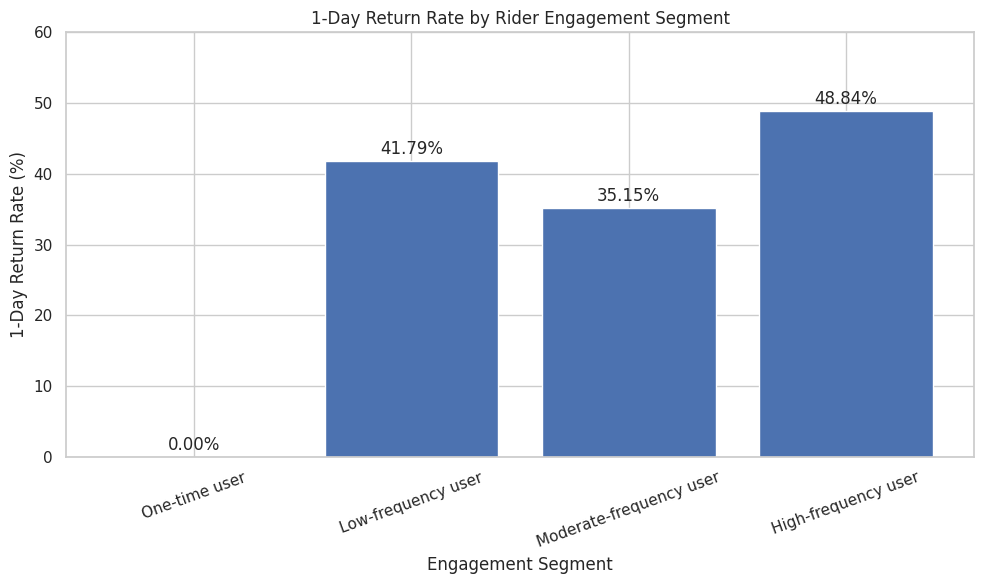

In [198]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    engagement_final["engagement_segment"].astype(str),
    engagement_final["return_1d"]
)

plt.xlabel("Engagement Segment")
plt.ylabel("1-Day Return Rate (%)")
plt.title("1-Day Return Rate by Rider Engagement Segment")
plt.xticks(rotation=20)
plt.ylim(0, 60)

for i, value in enumerate(engagement_final["return_1d"]):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

## 13. Cross-Factor Synthesis & Root-Cause Assessment

The previous sections examined network performance, service failures, geographic and station patterns, battery and equipment characteristics, pricing and partner economics, and rider retention.

This section brings these findings together to identify which factors show the strongest observed associations with service failures, retention, and margin performance.

Factors are classified as primary observed signals, secondary contributors, or weak/unclear signals based on the magnitude and consistency of the evidence found in the analysis.

These classifications describe observed associations in the dataset and do not establish causation.

In [199]:
# Build a cross-factor evidence matrix from the completed analyses

evidence_matrix = pd.DataFrame([
    {
        "business_area": "Service failures",
        "factor": "Battery manufacturing lot",
        "evidence": "Later manufacturing lots showed materially higher failure rates than earlier lots.",
        "role": "Primary observed signal"
    },
    {
        "business_area": "Service failures",
        "factor": "Charger generation",
        "evidence": "Gen 1 had a higher failure rate than Gen 2 and Gen 3.",
        "role": "Primary observed signal"
    },
    {
        "business_area": "Service failures",
        "factor": "Geography",
        "evidence": "Failure rates varied across cities, with Jaipur notably above Mumbai.",
        "role": "Secondary contributor"
    },
    {
        "business_area": "Service failures",
        "factor": "Battery SOH",
        "evidence": "Average SOH was similar for failed and completed events.",
        "role": "Weak / unclear signal"
    },
    {
        "business_area": "Service failures",
        "factor": "Battery supplier",
        "evidence": "Supplier failure rates differed, but the differences were smaller than the strongest manufacturing-lot effects.",
        "role": "Secondary contributor"
    },
    {
        "business_area": "Retention",
        "factor": "First-swap wait",
        "evidence": "Returned and non-returned riders had almost identical average first-swap wait.",
        "role": "Weak / unclear signal"
    },
    {
        "business_area": "Retention",
        "factor": "Prior first-swap failure",
        "evidence": "1-day return was 48.27% without prior failure versus 49.91% with prior failure.",
        "role": "Weak / unclear signal"
    },
    {
        "business_area": "Retention",
        "factor": "Rider engagement",
        "evidence": "High-frequency users showed stronger repeat behavior, although engagement is partly constructed from observed usage.",
        "role": "Strong observed association"
    },
    {
        "business_area": "Margin",
        "factor": "Partner pricing and discounts",
        "evidence": "PARTNER transactions generated 64.59% of observed revenue, with substantial variation in discounts.",
        "role": "Primary observed signal"
    },
    {
        "business_area": "Margin",
        "factor": "ZipDrop contract amendment",
        "evidence": "Contract discount increased from 12% to 28%, while observed revenue per swap fell from ₹57.48 to ₹48.65 after the amendment.",
        "role": "Primary observed signal"
    },
    {
        "business_area": "Margin",
        "factor": "Vehicle class",
        "evidence": "3W partners had substantially higher average charges per swap than most 2W partners.",
        "role": "Secondary contextual factor"
    },
    {
        "business_area": "Network performance",
        "factor": "Growth versus service quality",
        "evidence": "Swap volume and revenue increased while failure rates temporarily spiked during Apr-Jun.",
        "role": "Primary network-level signal"
    }
])

print("Cross-Factor Evidence Matrix")
print("=" * 100)

print(
    evidence_matrix[
        ["business_area", "factor", "role", "evidence"]
    ].to_string(index=False)
)

Cross-Factor Evidence Matrix
      business_area                        factor                         role                                                                                                                     evidence
   Service failures     Battery manufacturing lot      Primary observed signal                                           Later manufacturing lots showed materially higher failure rates than earlier lots.
   Service failures            Charger generation      Primary observed signal                                                                        Gen 1 had a higher failure rate than Gen 2 and Gen 3.
   Service failures                     Geography        Secondary contributor                                                        Failure rates varied across cities, with Jaipur notably above Mumbai.
   Service failures                   Battery SOH        Weak / unclear signal                                                                     Average 

## 13.2 Evidence Strength Across Findings

The evidence matrix is summarized by classification to show how many findings fall into each evidence category.

This is not a statistical score or ranking. It is a structured summary of the qualitative assessment made from the completed analyses.

In [200]:
role_summary = (
    evidence_matrix["role"]
    .value_counts()
    .rename_axis("evidence_role")
    .reset_index(name="number_of_findings")
)

print(role_summary.to_string(index=False))

               evidence_role  number_of_findings
     Primary observed signal                   4
       Weak / unclear signal                   3
       Secondary contributor                   2
 Strong observed association                   1
 Secondary contextual factor                   1
Primary network-level signal                   1


## 13.3 Root-Cause Interpretation

Across the completed analysis, the evidence suggests that VoltRelay's challenges are not explained by one universal factor.

Service failures show stronger associations with equipment-related cohorts and charger generation, with geographic differences providing additional operational context. Battery SOH by itself does not clearly distinguish failed from completed swaps.

For rider retention, first-swap operational friction does not appear to be a strong discriminator of 1-day return behavior. The largest observed differences are associated with rider engagement, city, and fleet partner, although these relationships should not be interpreted as causal.

For margin performance, commercial structure appears more important. Partner pricing and discounts account for a large share of realized revenue, and the ZipDrop contract amendment is a notable example where a substantially higher contracted discount coincided with lower observed revenue per swap. The short post-amendment observation period limits the strength of this conclusion.

At the network level, growth and service quality did not always move together. Transaction volume and revenue increased substantially, while failure rates temporarily increased during the Apr-Jun period.

Overall, the evidence points toward a combination of operational/equipment issues and commercial pricing pressure rather than a single root cause.

## 14. What VoltRelay Should Prioritize

The recommendations below are based on the strongest observed patterns in the completed analysis.

They are priorities for investigation and operational action, not claims of causal impact. The analysis is observational, so interventions should be validated through monitoring or controlled testing where possible.

The priorities focus on three areas: equipment reliability, commercial economics, and network scaling discipline.

In [201]:
priority_framework = pd.DataFrame([
    {
        "priority": "1. Improve equipment reliability",
        "evidence": "Later battery manufacturing lots and older charger generation showed higher observed failure rates.",
        "action": "Audit affected battery lots and Gen 1 chargers; prioritize inspection, maintenance, replacement or controlled retirement.",
        "metric_to_monitor": "Failure rate by battery lot and charger generation"
    },
    {
        "priority": "2. Protect partner unit economics",
        "evidence": "PARTNER transactions generated 64.59% of observed revenue and discount levels varied substantially.",
        "action": "Review partner discounts, contract terms and realized revenue per swap.",
        "metric_to_monitor": "Revenue per completed swap and contribution margin per swap"
    },
    {
        "priority": "3. Review major contract amendments",
        "evidence": "ZipDrop discount increased from 12% to 28%, coinciding with lower observed revenue per swap.",
        "action": "Evaluate large discount changes against volume, revenue and contribution margin before extending similar terms.",
        "metric_to_monitor": "Revenue and contribution margin before and after contract changes"
    },
    {
        "priority": "4. Scale without sacrificing reliability",
        "evidence": "Network volume and revenue increased while failure rates temporarily rose during Apr-Jun.",
        "action": "Track service-quality KPIs alongside expansion and volume growth.",
        "metric_to_monitor": "Failure rate, queue wait and completed swaps per station"
    },
    {
        "priority": "5. Monitor rider engagement",
        "evidence": "Engagement segments showed stronger differences in repeat behavior than the tested first-swap friction variables.",
        "action": "Monitor early rider engagement and investigate differences across rider and partner segments.",
        "metric_to_monitor": "1-day and 7-day return rates by rider segment"
    }
])

print("VoltRelay Priority Framework")
print("=" * 100)

print(priority_framework.to_string(index=False))

VoltRelay Priority Framework
                                priority                                                                                                          evidence                                                                                                                    action                                                 metric_to_monitor
        1. Improve equipment reliability               Later battery manufacturing lots and older charger generation showed higher observed failure rates. Audit affected battery lots and Gen 1 chargers; prioritize inspection, maintenance, replacement or controlled retirement.                Failure rate by battery lot and charger generation
       2. Protect partner unit economics               PARTNER transactions generated 64.59% of observed revenue and discount levels varied substantially.                                                   Review partner discounts, contract terms and realized revenue per swap.       Re

# 15. Final Conclusion

The analysis provides an evidence-based view of VoltRelay's network performance across operations, equipment, geography, pricing, partner economics, and rider retention.

Overall, the network experienced substantial growth in swap activity and revenue over the observed period. However, network growth did not always coincide with consistent service quality, as failure rates temporarily increased during April–June.

The strongest observed service-failure patterns were associated with equipment characteristics. Later battery manufacturing lots showed higher failure rates than earlier lots, while Gen 1 chargers also showed higher failure rates than newer charger generations. Geographic and supplier-level differences provided additional operational context, while battery state of health alone did not clearly distinguish failed from completed swaps.

Pricing and partner economics were another important area of variation. PARTNER transactions represented the largest share of observed revenue, and discount structures differed considerably across partners. The ZipDrop contract amendment, which increased the contracted discount from 12% to 28%, coincided with a reduction in observed revenue per swap. Because the post-amendment period was short, this should be interpreted as an observed association rather than proof of causality.

For rider retention, first-swap waiting time and prior first-swap failure did not show strong differences between riders who returned and those who did not. Rider engagement showed stronger variation in repeat behavior, although engagement is partly based on subsequent observed usage and therefore should not be interpreted as a causal driver.

Based on the combined evidence, VoltRelay should prioritize improving equipment reliability, protecting partner unit economics, carefully evaluating major contract amendments, and scaling network capacity while continuously monitoring service quality. Rider engagement should also be monitored as an important behavioral indicator.

These findings are based on observational data. The identified relationships describe patterns in the available data and do not establish causality. Future analysis using controlled experiments, longer post-intervention periods, and additional operational variables could strengthen the conclusions.

**Overall, the evidence suggests that VoltRelay's performance challenge is not driven by a single factor, but by the interaction of operational reliability, commercial economics, network growth, and rider behavior.**
